In [2]:

import pandas as pd
import numpy as np
from typing import Optional

PARAM_CSV_HOMO = (
    "/opt/domain-adaptation-people-counting/results/"
    "parameter_based_transfer/all_parameter_based_homogeneous.csv"
)

PARAM_CSV_HETERO = (
    "/opt/domain-adaptation-people-counting/results/"
    "parameter_based_transfer/all_parameter_based_heterogeneous.csv"
)

# ------------------------------------------------------------
# Map result-file method names to paper-table method names
# Keep TSW and TSBW as separate columns
# Keep only LinInt(alpha=0.50) and LinInt(alpha=0.75)
# ------------------------------------------------------------
def map_method_for_paper(method_name: str) -> Optional[str]:
    # Uses FT? = Yes
    if method_name == "Full-Fine-Tuning":
        return "Full-Fine-Tuning"
    if method_name == "Feature-Extraction":
        return "Feature-Extraction"
    if method_name == "Label-Aware Joint FT (tsw)":
        return "LA-Joint FT (TSW)"
    if method_name == "Label-Aware Joint FT (tsbw)":
        return "LA-Joint FT (TSBW)"
    if method_name == "Label-Aware Pretrain to Target FT (tsw)":
        return "LA-Pretrain → TgtFT (TSW)"
    if method_name == "Label-Aware Pretrain to Target FT (tsbw)":
        return "LA-Pretrain → TgtFT (TSBW)"
    if method_name == "Target-Priority Joint FT (tsw)":
        return "Target-Priority Joint FT (TSW)"
    if method_name == "Target-Priority Joint FT (tsbw)":
        return "Target-Priority Joint FT (TSBW)"
    if method_name == "Thresholded Label-Aware FT (tsw)":
        return "Thresh-LA FT (TSW)"
    if method_name == "Thresholded Label-Aware FT (tsbw)":
        return "Thresh-LA FT (TSBW)"

    # Uses FT? = No
    if method_name == "Direct-Transfer":
        return "Direct Transfer"
    if method_name == "Joint-Training":
        return "Joint-Training"
    if method_name == "Label-Aware Source Training (tsw)":
        return "LA-SrcTraining (TSW)"
    if method_name == "Label-Aware Source Training (tsbw)":
        return "LA-SrcTraining (TSBW)"
    if method_name == "Thresholded Label-Aware Source Training (tsw)":
        return "Thresh-LA-SrcTraining (TSW)"
    if method_name == "Thresholded Label-Aware Source Training (tsbw)":
        return "Thresh-LA-SrcTraining (TSBW)"
    if method_name == "LinInt (alpha=0.50)":
        return "LinInt (0.50)"
    if method_name == "LinInt (alpha=0.75)":
        return "LinInt (0.75)"
    if method_name == "Source Model + Target Calibration":
        return "SrcModel + TgtCalibration"
    if method_name == "Source-to-Target Linear Mapping":
        return "Source-to-TgtLinear Mapping"
    if method_name == "Target-Only":
        return "Target-Only"

    return None


# ------------------------------------------------------------
# Column order matching paper-table method order
# ------------------------------------------------------------
method_order = [
    # Uses FT? = Yes
    "Full-Fine-Tuning",
    "Feature-Extraction",
    "LA-Joint FT (TSW)",
    "LA-Joint FT (TSBW)",
    "LA-Pretrain → TgtFT (TSW)",
    "LA-Pretrain → TgtFT (TSBW)",
    "Target-Priority Joint FT (TSW)",
    "Target-Priority Joint FT (TSBW)",
    "Thresh-LA FT (TSW)",
    "Thresh-LA FT (TSBW)",

    # Uses FT? = No
    "Direct Transfer",
    "Joint-Training",
    "LA-SrcTraining (TSW)",
    "LA-SrcTraining (TSBW)",
    "Thresh-LA-SrcTraining (TSW)",
    "Thresh-LA-SrcTraining (TSBW)",
    "LinInt (0.50)",
    "LinInt (0.75)",
    "SrcModel + TgtCalibration",
    "Source-to-TgtLinear Mapping",
    "Target-Only",
]

backbone_order = ["RNN", "LSTM", "Transformer"]


# ------------------------------------------------------------
# Shared helper — builds display_df from a CSV path
# decimals=2 gives paper-ready values like 0.237 -> 0.24
# ------------------------------------------------------------
def build_table(param_csv: str, decimals: int = 2):
    df = pd.read_csv(param_csv)

    df["paper_method"] = df["method"].apply(map_method_for_paper)
    paper_df = df[df["paper_method"].notna()].copy()

    agg_df = (
        paper_df
        .groupby(["scenario", "model", "paper_method"], as_index=False)["test_mae"]
        .min()
    )

    scenario_order = list(dict.fromkeys(agg_df["scenario"].tolist()))

    wide = agg_df.pivot_table(
        index=["scenario", "model"],
        columns="paper_method",
        values="test_mae",
        aggfunc="first"
    ).reset_index()

    for col in method_order:
        if col not in wide.columns:
            wide[col] = np.nan

    wide = wide[["scenario", "model"] + method_order]

    wide["scenario"] = pd.Categorical(
        wide["scenario"],
        categories=scenario_order,
        ordered=True
    )
    wide["model"] = pd.Categorical(
        wide["model"],
        categories=backbone_order,
        ordered=True
    )

    wide = wide.sort_values(["scenario", "model"]).reset_index(drop=True)
    wide = wide.rename(columns={"scenario": "Setting", "model": "Backbone"})

    display_df = wide.copy()

    for col in method_order:
        display_df[col] = display_df[col].map(
            lambda x: f"{x:.{decimals}f}" if pd.notna(x) else ""
        )

    return display_df


# ============================================================
# TABLE 1 — HOMOGENEOUS
# ============================================================
display_homo = build_table(PARAM_CSV_HOMO, decimals=2)

print("\nPaper-style MAE table — HOMOGENEOUS — separate TSW / TSBW columns:\n")
print(display_homo.to_string(index=False))

display_homo.to_csv("parameter_based_paper_table_homogeneous.csv", index=False)

latex_str = display_homo.to_latex(index=False, escape=False)
with open("parameter_based_paper_table_homogeneous.tex", "w") as f:
    f.write(latex_str)

print("\nSaved:")
print(" - parameter_based_paper_table_homogeneous.csv")
print(" - parameter_based_paper_table_homogeneous.tex")


# ============================================================
# TABLE 2 — HETEROGENEOUS
# ============================================================
display_hetero = build_table(PARAM_CSV_HETERO, decimals=2)

print("\nPaper-style MAE table — HETEROGENEOUS — separate TSW / TSBW columns:\n")
print(display_hetero.to_string(index=False))

display_hetero.to_csv("parameter_based_paper_table_heterogeneous.csv", index=False)

latex_str = display_hetero.to_latex(index=False, escape=False)
with open("parameter_based_paper_table_heterogeneous.tex", "w") as f:
    f.write(latex_str)

print("\nSaved:")
print(" - parameter_based_paper_table_heterogeneous.csv")
print(" - parameter_based_paper_table_heterogeneous.tex")




Paper-style MAE table — HOMOGENEOUS — separate TSW / TSBW columns:

         Setting    Backbone Full-Fine-Tuning Feature-Extraction LA-Joint FT (TSW) LA-Joint FT (TSBW) LA-Pretrain → TgtFT (TSW) LA-Pretrain → TgtFT (TSBW) Target-Priority Joint FT (TSW) Target-Priority Joint FT (TSBW) Thresh-LA FT (TSW) Thresh-LA FT (TSBW) Direct Transfer Joint-Training LA-SrcTraining (TSW) LA-SrcTraining (TSBW) Thresh-LA-SrcTraining (TSW) Thresh-LA-SrcTraining (TSBW) LinInt (0.50) LinInt (0.75) SrcModel + TgtCalibration Source-to-TgtLinear Mapping Target-Only
Room_A -> Room_B         RNN             0.24               0.28              0.35               0.28                      0.24                       0.24                           0.33                            0.27               0.42                0.28            0.33           0.28                 0.29                  0.30                        0.28                         0.28          0.25          0.21                      0.52        

Saved: /opt/domain-adaptation-people-counting/results/parameter_based_transfer/figures/heterogeneous_delta_heatmap.png
Saved: /opt/domain-adaptation-people-counting/results/parameter_based_transfer/figures/heterogeneous_delta_heatmap.pdf


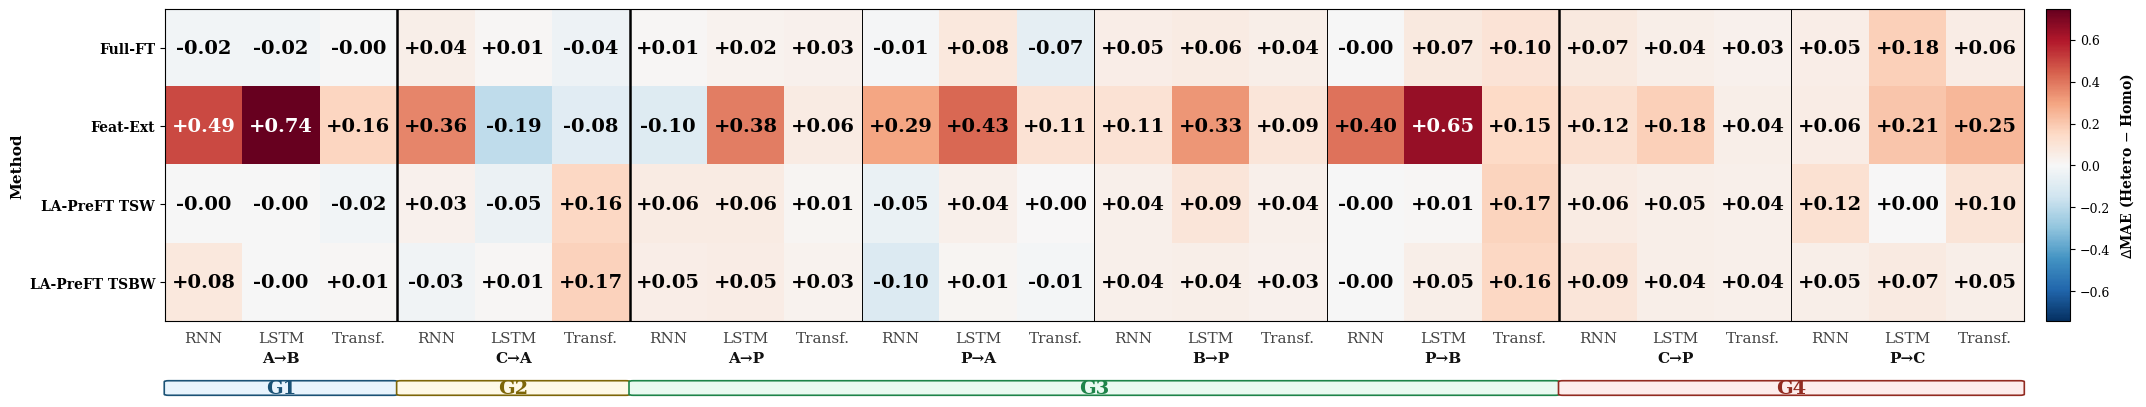


Mean ΔMAE by method:
Full-FT          0.0334
Feat-Ext         0.2180
LA-PreFT TSW     0.0396
LA-PreFT TSBW    0.0380


In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif":  ["Times New Roman", "DejaVu Serif"],
    "font.size":   9,
    "axes.linewidth": 0.8,
})

# ── paths ──────────────────────────────────────────────────────────────────
PARAM_CSV_HOMO = (
    "/opt/domain-adaptation-people-counting/results/"
    "parameter_based_transfer/all_parameter_based_homogeneous.csv"
)
PARAM_CSV_HETERO = (
    "/opt/domain-adaptation-people-counting/results/"
    "parameter_based_transfer/all_parameter_based_heterogeneous.csv"
)
FIGURE_DIR = Path(
    "/opt/domain-adaptation-people-counting/results/"
    "parameter_based_transfer/figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ── methods (Target-Only REMOVED) ───────────────────────────────────────────
METHOD_MAP = {
    "Full-Fine-Tuning":                         "Full-FT",
    "Feature-Extraction":                       "Feat-Ext",
    "Label-Aware Pretrain to Target FT (tsw)":  "LA-PreFT TSW",
    "Label-Aware Pretrain to Target FT (tsbw)": "LA-PreFT TSBW",
}
METHOD_ORDER = ["Full-FT", "Feat-Ext", "LA-PreFT TSW", "LA-PreFT TSBW"]

# ── settings / backbones ────────────────────────────────────────────────────
SETTING_ORDER = [
    "Room_A -> Room_B",
    "Room_C -> Room_A",
    "Room_A -> Room_P",
    "Room_P -> Room_A",
    "Room_B -> Room_P",
    "Room_P -> Room_B",
    "Room_C -> Room_P",
    "Room_P -> Room_C",
]
BACKBONE_ORDER = ["RNN", "LSTM", "Transformer"]
BACKBONE_SHORT = {"RNN": "RNN", "LSTM": "LSTM", "Transformer": "Transf."}

PAIR_LABEL = {
    "Room_A -> Room_B": "A→B", "Room_C -> Room_A": "C→A",
    "Room_A -> Room_P": "A→P", "Room_P -> Room_A": "P→A",
    "Room_B -> Room_P": "B→P", "Room_P -> Room_B": "P→B",
    "Room_C -> Room_P": "C→P", "Room_P -> Room_C": "P→C",
}
GROUP_MAP = {
    "Room_A -> Room_B": "G1", "Room_C -> Room_A": "G2",
    "Room_A -> Room_P": "G3", "Room_P -> Room_A": "G3",
    "Room_B -> Room_P": "G3", "Room_P -> Room_B": "G3",
    "Room_C -> Room_P": "G4", "Room_P -> Room_C": "G4",
}
GROUP_FILL = {"G1": "#E8F4FD", "G2": "#FEF9E7", "G3": "#EAFAF1", "G4": "#FDEDEC"}
GROUP_EDGE = {"G1": "#1A5276", "G2": "#7D6608", "G3": "#1E8449", "G4": "#922B21"}

# ── build wide table ────────────────────────────────────────────────────────
def build_wide(csv_path):
    df = pd.read_csv(csv_path)
    df["pm"] = df["method"].map(METHOD_MAP)
    df = df[df["pm"].notna()].copy()
    agg = df.groupby(["scenario", "model", "pm"], as_index=False)["test_mae"].min()
    wide = agg.pivot_table(index=["scenario", "model"], columns="pm",
                           values="test_mae", aggfunc="first").reset_index()
    wide = wide.rename(columns={"scenario": "Setting", "model": "Backbone"})
    for m in METHOD_ORDER:
        if m not in wide.columns:
            wide[m] = np.nan
    return wide[["Setting", "Backbone"] + METHOD_ORDER]

homo   = build_wide(PARAM_CSV_HOMO)
hetero = build_wide(PARAM_CSV_HETERO)
homo   = homo[homo["Setting"].isin(SETTING_ORDER)].copy()
hetero = hetero[hetero["Setting"].isin(SETTING_ORDER)].copy()

merged = hetero.merge(homo, on=["Setting", "Backbone"], suffixes=("_h", "_o"))
delta  = merged[["Setting", "Backbone"]].copy()
for m in METHOD_ORDER:
    delta[m] = merged[f"{m}_h"] - merged[f"{m}_o"]

# ── matrix: rows = methods, cols = setting × backbone ───────────────────────
col_keys = [(s, b) for s in SETTING_ORDER for b in BACKBONE_ORDER]
n_cols, n_rows = len(col_keys), len(METHOD_ORDER)

matrix = np.full((n_rows, n_cols), np.nan)
for ci, (setting, backbone) in enumerate(col_keys):
    row = delta[(delta["Setting"] == setting) & (delta["Backbone"] == backbone)]
    if len(row) == 0:
        continue
    for ri, method in enumerate(METHOD_ORDER):
        matrix[ri, ci] = float(row[method].values[0])

# ── color scale ──────────────────────────────────────────────────────────────
vabs = np.nanmax(np.abs(matrix))
norm = TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)

# ── figure ───────────────────────────────────────────────────────────────────
FIG_W, FIG_H, BOTTOM = 22, 5.2, 0.30
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
fig.subplots_adjust(left=0.085, right=0.93, top=0.90, bottom=BOTTOM)

im = ax.imshow(matrix, aspect="auto", cmap="RdBu_r", norm=norm)

# cell values
for ri in range(n_rows):
    for ci in range(n_cols):
        v = matrix[ri, ci]
        if np.isnan(v):
            continue
        nv = norm(v)
        tc = "white" if (nv < 0.18 or nv > 0.82) else "black"
        ax.text(ci, ri, f"{v:+.2f}", ha="center", va="center",
                fontsize=14, fontweight="bold", color=tc)

# vertical dividers (thick at group change, thin between backbones)
for ci in range(3, n_cols, 3):
    s_left, s_right = col_keys[ci - 1][0], col_keys[ci][0]
    lw = 1.8 if GROUP_MAP[s_left] != GROUP_MAP[s_right] else 0.7
    ax.axvline(ci - 0.5, color="black", linewidth=lw, zorder=5)

# y-axis
ax.set_yticks(range(n_rows))
ax.set_yticklabels(METHOD_ORDER, fontsize=10, fontweight="bold")
ax.set_ylabel("Method", fontsize=11, fontweight="bold")

# hide native x ticks — we draw a 3-tier axis below
ax.set_xticks([])
ax.tick_params(axis="x", length=0)

ax_to_fig = ax.transData + fig.transFigure.inverted()
pos = ax.get_position()

# tier 1: backbone abbreviation (directly under each column)
for ci, (setting, backbone) in enumerate(col_keys):
    xf, _ = ax_to_fig.transform((ci, 0))
    fig.text(xf, pos.y0 - 0.020, BACKBONE_SHORT[backbone],
             ha="center", va="top", fontsize=11, color="#444444",
             transform=fig.transFigure)

# tier 2: pair label (centered over its 3 backbone columns)
seen = set()
for ci, (setting, _) in enumerate(col_keys):
    if setting in seen:
        continue
    seen.add(setting)
    xf, _ = ax_to_fig.transform((ci + 1.0, 0))
    fig.text(xf, pos.y0 - 0.058, PAIR_LABEL[setting],
             ha="center", va="top", fontsize=11, fontweight="bold",
             color="#111111", transform=fig.transFigure)

# tier 3: group band (rounded colored rectangle spanning the group)
spans = {}
for ci, (setting, _) in enumerate(col_keys):
    g = GROUP_MAP[setting]
    spans.setdefault(g, [ci, ci])
    spans[g][1] = ci
for g, (c0, c1) in spans.items():
    xL, _ = ax_to_fig.transform((c0 - 0.45, 0))
    xR, _ = ax_to_fig.transform((c1 + 0.45, 0))
    yb, hh = pos.y0 - 0.140, 0.024
    fig.add_artist(mpatches.FancyBboxPatch(
        (xL, yb), xR - xL, hh, boxstyle="round,pad=0.002",
        linewidth=1.2, edgecolor=GROUP_EDGE[g], facecolor=GROUP_FILL[g],
        transform=fig.transFigure, clip_on=False, zorder=6))
    fig.text((xL + xR) / 2, yb + hh / 2, g, ha="center", va="center",
             fontsize=14, fontweight="bold", color=GROUP_EDGE[g],
             transform=fig.transFigure, zorder=7)

# colorbar
cax = fig.add_axes([0.94, BOTTOM, 0.011, 0.90 - BOTTOM])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"$\Delta$MAE (Hetero $-$ Homo)", fontsize=10, fontweight="bold", labelpad=6)
cbar.ax.tick_params(labelsize=9)



for ext in ["png", "pdf"]:
    out = FIGURE_DIR / f"heterogeneous_delta_heatmap.{ext}"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved: {out}")

plt.show()
plt.close()

# ── summary ──────────────────────────────────────────────────────────────────
df_out = pd.DataFrame(matrix, index=METHOD_ORDER,
                      columns=[f"{PAIR_LABEL[s]}|{b}" for s, b in col_keys])
df_out.to_csv(FIGURE_DIR / "heterogeneous_delta_matrix.csv")
print("\nMean ΔMAE by method:")
print(df_out.mean(axis=1).round(4).to_string())

GROUPED BAR - Homogeneous - one merged figure
  Rows: RNN, LSTM, Transformer
  9 directional settings, labeled with G1-G4
  Output: /opt/domain-adaptation-people-counting/results/parameter_based_transfer/figures


/tmp/ipykernel_4287/1262172605.py:361: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.savefig(out, dpi=600, bbox_inches="tight")


    Saved: /opt/domain-adaptation-people-counting/results/parameter_based_transfer/figures/grouped_bar_homogeneous_all_backbones.pdf


/tmp/ipykernel_4287/1262172605.py:361: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.savefig(out, dpi=600, bbox_inches="tight")


    Saved: /opt/domain-adaptation-people-counting/results/parameter_based_transfer/figures/grouped_bar_homogeneous_all_backbones.png


/home/azad/enter/envs/pytorch_gpu/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


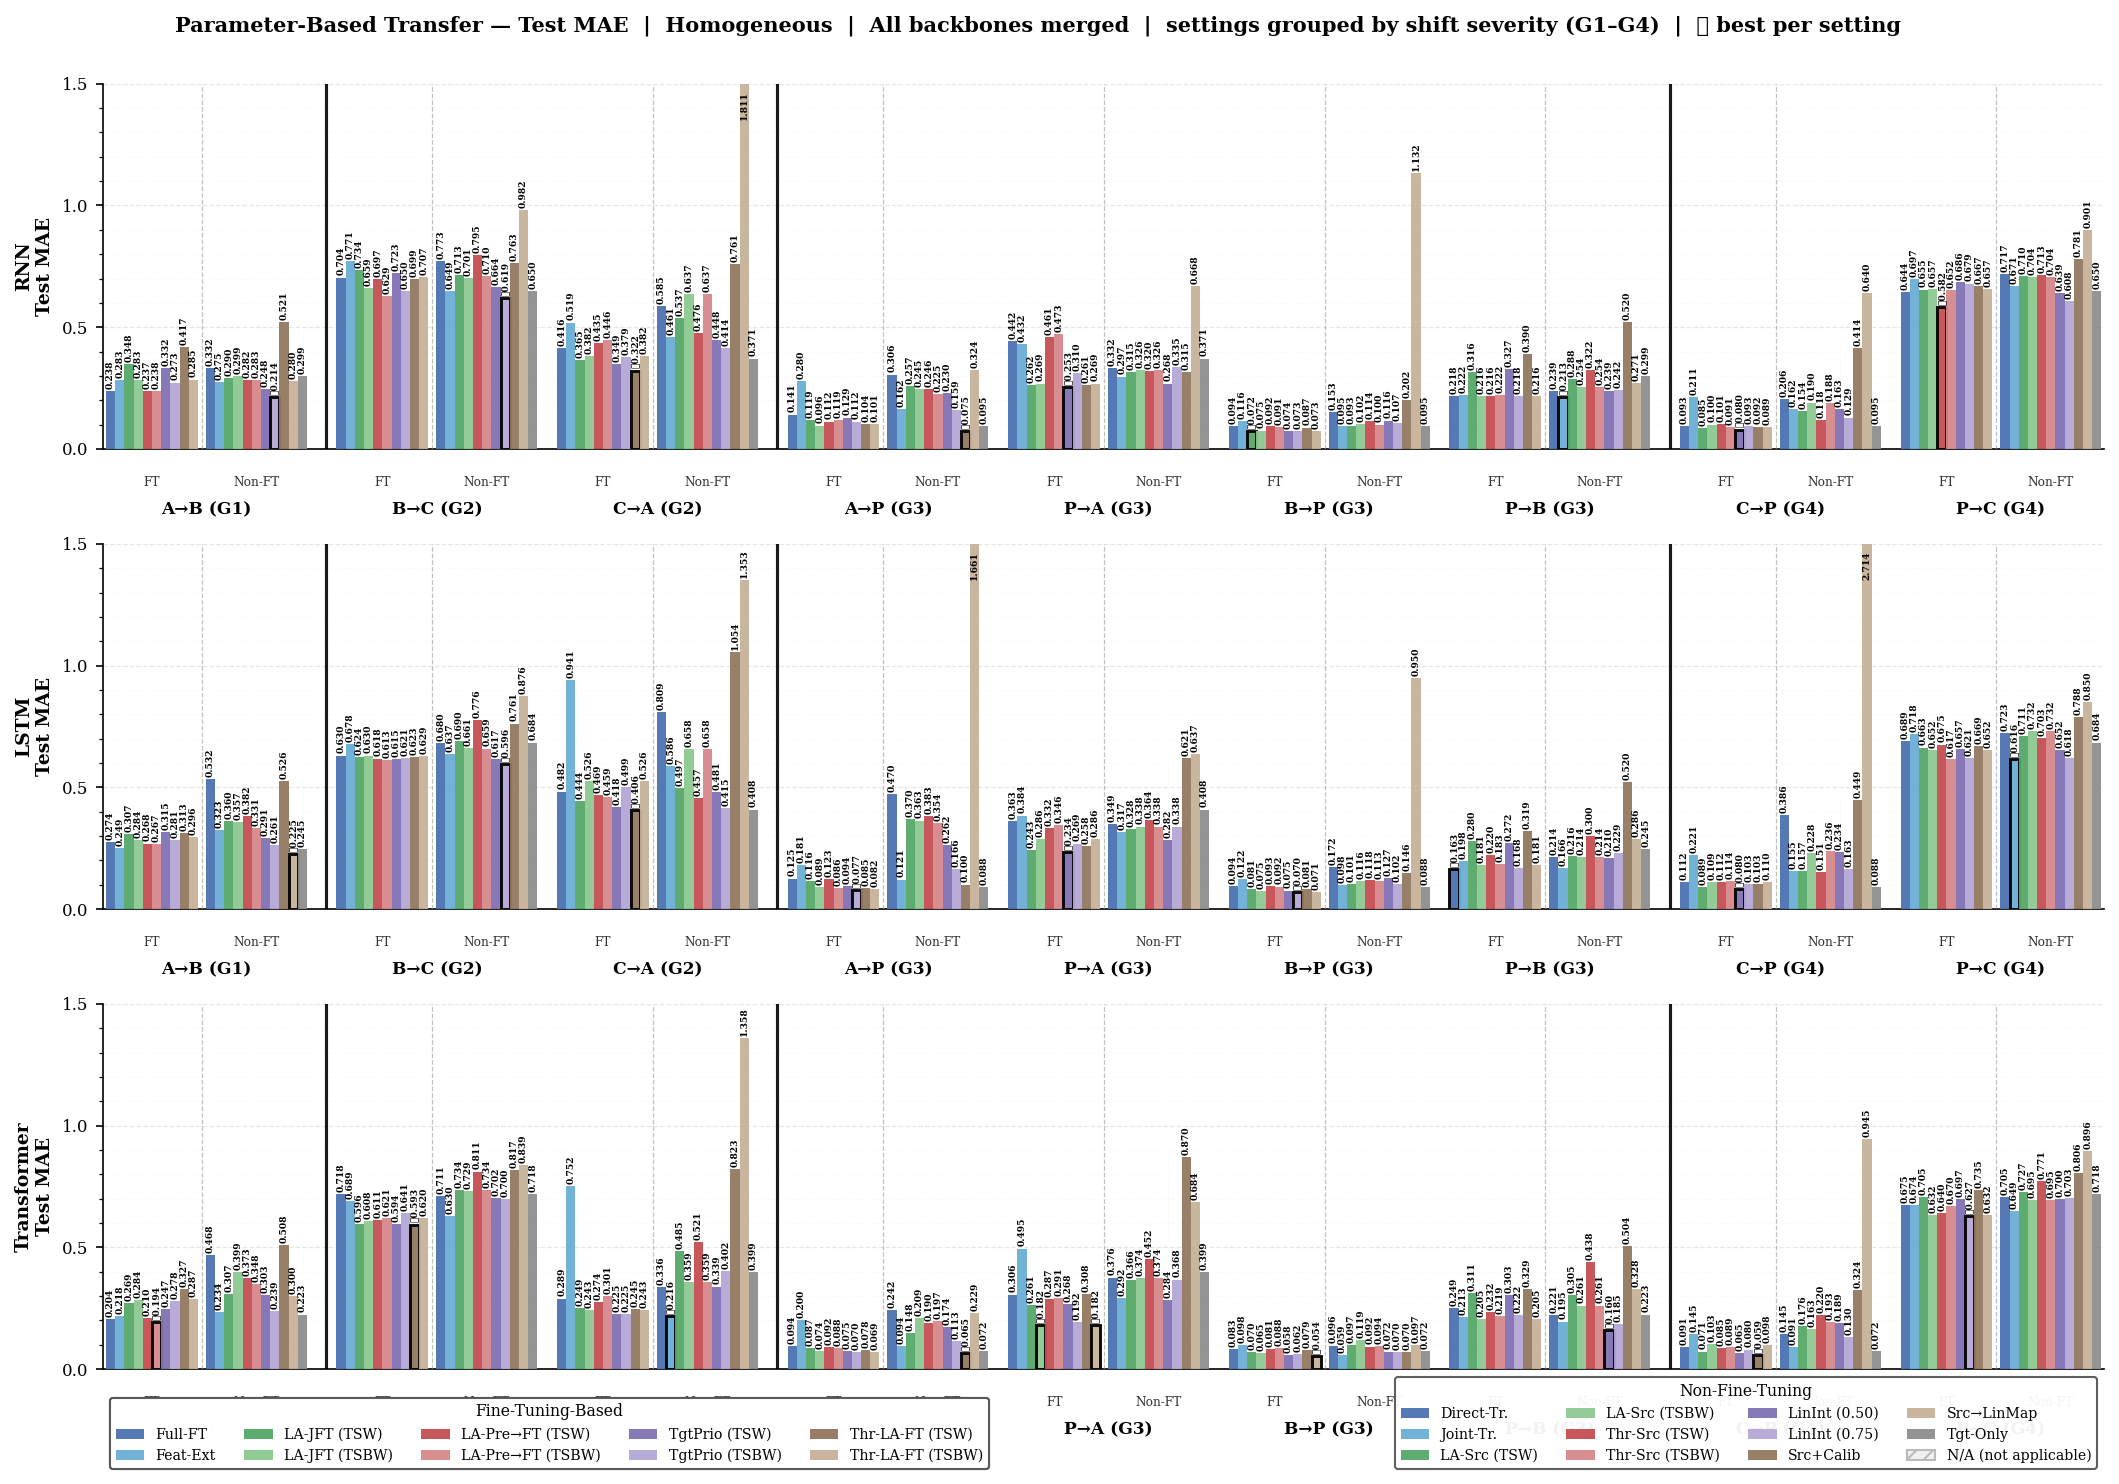


DONE -> /opt/domain-adaptation-people-counting/results/parameter_based_transfer/figures


In [12]:
"""
Parameter-Based Transfer — Grouped Bar Charts (Homogeneous, Publication Quality)

ONE figure total — all backbones merged.

Rows:
    RNN
    LSTM
    Transformer

Author: Azadshokrollahi
"""

import sys
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from typing import Optional

matplotlib.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          8,
    "axes.titlesize":     9,
    "axes.labelsize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "legend.fontsize":    7,
    "legend.title_fontsize": 7.5,
    "figure.dpi":         150,
    "savefig.dpi":        600,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
})

try:
    _SRC_DIR = Path(__file__).resolve().parent.parent / "src"
except NameError:
    _SRC_DIR = next(
        (p / "src"
         for p in [Path.cwd(), Path.cwd().parent]
         if (p / "src" / "config.py").exists()),
        Path.cwd(),
    )
if str(_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(_SRC_DIR))

from config import RESULTS_ROOT

PARAM_DIR  = RESULTS_ROOT / "parameter_based_transfer"
OUTPUT_DIR = PARAM_DIR / "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PARAM_CSV_HOMO = PARAM_DIR / "all_parameter_based_homogeneous.csv"


def map_method(name: str) -> Optional[str]:
    _MAP = {
        "Full-Fine-Tuning":                               "Full-FT",
        "Feature-Extraction":                             "Feat-Ext",
        "Label-Aware Joint FT (tsw)":                     "LA-JFT (TSW)",
        "Label-Aware Joint FT (tsbw)":                    "LA-JFT (TSBW)",
        "Label-Aware Pretrain to Target FT (tsw)":        "LA-Pre\u2192FT (TSW)",
        "Label-Aware Pretrain to Target FT (tsbw)":       "LA-Pre\u2192FT (TSBW)",
        "Target-Priority Joint FT (tsw)":                 "TgtPrio (TSW)",
        "Target-Priority Joint FT (tsbw)":                "TgtPrio (TSBW)",
        "Thresholded Label-Aware FT (tsw)":               "Thr-LA-FT (TSW)",
        "Thresholded Label-Aware FT (tsbw)":              "Thr-LA-FT (TSBW)",
        "Direct-Transfer":                                "Direct-Tr.",
        "Joint-Training":                                 "Joint-Tr.",
        "Label-Aware Source Training (tsw)":              "LA-Src (TSW)",
        "Label-Aware Source Training (tsbw)":             "LA-Src (TSBW)",
        "Thresholded Label-Aware Source Training (tsw)":  "Thr-Src (TSW)",
        "Thresholded Label-Aware Source Training (tsbw)": "Thr-Src (TSBW)",
        "LinInt (alpha=0.50)":                            "LinInt (0.50)",
        "LinInt (alpha=0.75)":                            "LinInt (0.75)",
        "Source Model + Target Calibration":              "Src+Calib",
        "Source-to-Target Linear Mapping":                "Src\u2192LinMap",
        "Target-Only":                                    "Tgt-Only",
    }
    return _MAP.get(name, None)


FT_METHODS = [
    "Full-FT", "Feat-Ext",
    "LA-JFT (TSW)", "LA-JFT (TSBW)",
    "LA-Pre\u2192FT (TSW)", "LA-Pre\u2192FT (TSBW)",
    "TgtPrio (TSW)", "TgtPrio (TSBW)",
    "Thr-LA-FT (TSW)", "Thr-LA-FT (TSBW)",
]

NON_FT_METHODS = [
    "Direct-Tr.", "Joint-Tr.",
    "LA-Src (TSW)", "LA-Src (TSBW)",
    "Thr-Src (TSW)", "Thr-Src (TSBW)",
    "LinInt (0.50)", "LinInt (0.75)",
    "Src+Calib", "Src\u2192LinMap", "Tgt-Only",
]

ALL_METHODS = FT_METHODS + NON_FT_METHODS
N_FT        = len(FT_METHODS)
N_NON_FT    = len(NON_FT_METHODS)

FT_COLORS = [
    "#4C72B0", "#6BAED6", "#55A868", "#8CC98F", "#C44E52",
    "#D6878A", "#8172B3", "#B4A7D6", "#937860", "#C7B299",
]
NON_FT_COLORS = [
    "#4C72B0", "#6BAED6", "#55A868", "#8CC98F",
    "#C44E52", "#D6878A", "#8172B3", "#B4A7D6",
    "#937860", "#C7B299", "#8E8E8E",
]

SCENARIO_SHORT = {
    "Room_A -> Room_B": "A\u2192B (G1)",
    "Room_B -> Room_C": "B\u2192C (G2)",
    "Room_C -> Room_A": "C\u2192A (G2)",
    "Room_A -> Room_P": "A\u2192P (G3)",
    "Room_P -> Room_A": "P\u2192A (G3)",
    "Room_B -> Room_P": "B\u2192P (G3)",
    "Room_P -> Room_B": "P\u2192B (G3)",
    "Room_C -> Room_P": "C\u2192P (G4)",
    "Room_P -> Room_C": "P\u2192C (G4)",
}

SHIFT_GROUPS = [
    ("G1 \u00b7 Lower shift",
        ["Room_A -> Room_B"]),
    ("G2 \u00b7 Conditional-dominated",
        ["Room_B -> Room_C", "Room_C -> Room_A"]),
    ("G3 \u00b7 Marginal + conditional",
        ["Room_A -> Room_P", "Room_P -> Room_A",
         "Room_B -> Room_P", "Room_P -> Room_B"]),
    ("G4 \u00b7 Marginal-dominated",
        ["Room_C -> Room_P", "Room_P -> Room_C"]),
]

SETTING_ORDER = [s for _, settings in SHIFT_GROUPS for s in settings]
BACKBONE_ORDER = ["RNN", "LSTM", "Transformer"]

BAR_W       = 0.14
INNER_GAP   = 0.12
SETTING_GAP = 0.30
GROUP_GAP   = 0.45

FS_VALUE     = 4.4
FS_VALUE_NA  = 3.8
FS_SUBGROUP  = 5.8
FS_SETTING   = 8.2
FS_GROUP     = 8.0

Y_CAP        = 1.5


def compute_x_positions():
    set_ft_x, set_nft_x = {}, {}
    set_label, set_divider = {}, {}
    group_div, group_span = [], []

    cursor = 0.0
    for g_idx, (glabel, settings) in enumerate(SHIFT_GROUPS):
        group_left = cursor
        for s_idx, scen in enumerate(settings):
            s_ft = [cursor + m * BAR_W for m in range(N_FT)]
            ft_end = s_ft[-1]
            nft_start = ft_end + BAR_W + INNER_GAP
            s_nft = [nft_start + m * BAR_W for m in range(N_NON_FT)]
            nft_end = s_nft[-1]

            set_ft_x[scen]    = s_ft
            set_nft_x[scen]   = s_nft
            set_label[scen]   = (s_ft[0] + s_nft[-1]) / 2
            set_divider[scen] = (ft_end + nft_start) / 2

            if s_idx < len(settings) - 1:
                cursor = nft_end + BAR_W + SETTING_GAP
            else:
                cursor = nft_end + BAR_W
        group_right = cursor
        group_span.append((glabel, (group_left + group_right) / 2))
        if g_idx < len(SHIFT_GROUPS) - 1:
            group_div.append(cursor + GROUP_GAP / 2)
            cursor = cursor + GROUP_GAP

    return set_ft_x, set_nft_x, set_label, set_divider, group_div, group_span


def load_pivot(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["paper_method"] = df["method"].apply(map_method)
    df = df[df["paper_method"].notna()].copy()
    agg = (
        df.groupby(["scenario", "model", "paper_method"], as_index=False)["test_mae"]
        .min()
    )
    wide = agg.pivot_table(
        index=["scenario", "model"],
        columns="paper_method",
        values="test_mae",
        aggfunc="first",
    ).reset_index()
    for col in ALL_METHODS:
        if col not in wide.columns:
            wide[col] = np.nan
    return wide[["scenario", "model"] + ALL_METHODS]


def draw_bars(ax, x_positions, methods, colors, row, best_val, ymax):
    for method, color, x in zip(methods, colors, x_positions):
        val = row[method] if method in row.index else np.nan
        if np.isnan(val):
            ax.bar(x, ymax * 0.04, width=BAR_W,
                   color="#F0F0F0", edgecolor="#BBBBBB",
                   linewidth=0.5, hatch="///", zorder=2)
            ax.text(x, ymax * 0.05, "n/a", ha="center", va="bottom",
                    fontsize=FS_VALUE_NA, color="#999999", rotation=90)
            continue

        is_best = abs(val - best_val) < 1e-9
        draw_val = min(val, ymax)
        is_clipped = val > ymax

        ax.bar(x, draw_val, width=BAR_W, color=color,
               edgecolor="black" if is_best else "none",
               linewidth=1.4 if is_best else 0.0,
               alpha=0.95, zorder=3)

        label = ("\u2605" + f"{val:.3f}") if is_best else f"{val:.3f}"
        ytext = (ymax - ymax * 0.02) if is_clipped else (draw_val + ymax * 0.006)
        vatext = "top" if is_clipped else "bottom"

        ax.text(x, ytext, label, ha="center", va=vatext,
                fontsize=FS_VALUE, fontweight="bold", color="black",
                rotation=90, zorder=5)


def plot_all_backbones(wide_df: pd.DataFrame):
    (set_ft_x, set_nft_x, set_label,
     set_divider, group_div, group_span) = compute_x_positions()

    ymax = Y_CAP
    ymin = 0.0

    fig, axes = plt.subplots(
        nrows=len(BACKBONE_ORDER),
        ncols=1,
        figsize=(14.5, 10.2),
        sharex=True,
        sharey=True,
    )

    fig.subplots_adjust(bottom=0.09, top=0.93, left=0.07, right=0.99, hspace=0.26)

    for ax, backbone in zip(axes, BACKBONE_ORDER):
        sub = wide_df[wide_df["model"] == backbone].copy()

        set_rows = {}
        for scen in SETTING_ORDER:
            rows = sub[sub["scenario"] == scen]
            if len(rows):
                set_rows[scen] = rows.iloc[0]

        if not set_rows:
            print(f"  No matching settings for {backbone}")
            continue

        for scen in SETTING_ORDER:
            if scen not in set_rows:
                continue

            row = set_rows[scen]
            best_val = float(np.nanmin([row[m] for m in ALL_METHODS]))

            draw_bars(ax, set_ft_x[scen],  FT_METHODS,     FT_COLORS,
                      row, best_val, ymax)
            draw_bars(ax, set_nft_x[scen], NON_FT_METHODS, NON_FT_COLORS,
                      row, best_val, ymax)

            ax.axvline(set_divider[scen], color="#999999",
                       linewidth=0.6, linestyle="--", alpha=0.6, zorder=4)

            ft_cx  = (set_ft_x[scen][0]  + set_ft_x[scen][-1])  / 2
            nft_cx = (set_nft_x[scen][0] + set_nft_x[scen][-1]) / 2

            ax.annotate("FT", xy=(ft_cx, 0), xycoords=("data", "axes fraction"),
                        xytext=(0, -13), textcoords="offset points",
                        ha="center", va="top", fontsize=FS_SUBGROUP,
                        color="#333333", annotation_clip=False)

            ax.annotate("Non-FT", xy=(nft_cx, 0), xycoords=("data", "axes fraction"),
                        xytext=(0, -13), textcoords="offset points",
                        ha="center", va="top", fontsize=FS_SUBGROUP,
                        color="#333333", annotation_clip=False)

            ax.annotate(SCENARIO_SHORT[scen], xy=(set_label[scen], 0),
                        xycoords=("data", "axes fraction"),
                        xytext=(0, -25), textcoords="offset points",
                        ha="center", va="top", fontsize=FS_SETTING,
                        fontweight="bold", color="black", annotation_clip=False)

        for gx in group_div:
            ax.axvline(gx, color="black", linewidth=1.5,
                       linestyle="-", alpha=0.9, zorder=6)

        ax.set_xticks([])
        ax.set_ylabel(f"{backbone}\nTest MAE", fontsize=9, fontweight="bold")
        ax.set_ylim(ymin, ymax)

        ax.yaxis.set_major_locator(MultipleLocator(0.5))
        ax.yaxis.set_minor_locator(MultipleLocator(0.1))

        ax.grid(True, axis="y", which="major",
                alpha=0.30, linestyle="--", linewidth=0.6, zorder=0)
        ax.grid(True, axis="y", which="minor",
                alpha=0.12, linestyle=":", linewidth=0.4, zorder=0)

    first_s = SETTING_ORDER[0]
    last_s  = SETTING_ORDER[-1]
    axes[-1].set_xlim(set_ft_x[first_s][0]  - BAR_W * 0.8,
                      set_nft_x[last_s][-1] + BAR_W * 0.8)

    fig.suptitle(
        "Parameter-Based Transfer \u2014 Test MAE  |  Homogeneous  |  "
        "All backbones merged  |  settings grouped by shift severity (G1\u2013G4)  |  "
        "\u2605 best per setting",
        fontsize=10, fontweight="bold", y=0.975,
    )

    ft_handles = [mpatches.Patch(facecolor=FT_COLORS[i], edgecolor="none",
                                 label=m, alpha=0.95)
                  for i, m in enumerate(FT_METHODS)]
    nft_handles = [mpatches.Patch(facecolor=NON_FT_COLORS[i], edgecolor="none",
                                  label=m, alpha=0.95)
                   for i, m in enumerate(NON_FT_METHODS)]
    na_handle = mpatches.Patch(facecolor="#F0F0F0", edgecolor="#BBBBBB",
                               hatch="///", label="N/A (not applicable)")

    leg_ft = fig.legend(handles=ft_handles, title="Fine-Tuning-Based",
                        loc="lower left", bbox_to_anchor=(0.07, 0.02),
                        ncol=5, fontsize=6.8, frameon=True,
                        edgecolor="#555555", framealpha=0.95)

    fig.add_artist(leg_ft)

    fig.legend(handles=nft_handles + [na_handle], title="Non-Fine-Tuning",
               loc="lower right", bbox_to_anchor=(0.99, 0.02),
               ncol=4, fontsize=6.8, frameon=True,
               edgecolor="#555555", framealpha=0.95)

    fname = "grouped_bar_homogeneous_all_backbones"
    for ext in ["pdf", "png"]:
        out = OUTPUT_DIR / f"{fname}.{ext}"
        fig.savefig(out, dpi=600, bbox_inches="tight")
        print(f"    Saved: {out}")

    plt.show()
    plt.close()


def main():
    print("=" * 70)
    print("GROUPED BAR - Homogeneous - one merged figure")
    print("  Rows: RNN, LSTM, Transformer")
    print("  9 directional settings, labeled with G1-G4")
    print(f"  Output: {OUTPUT_DIR}")
    print("=" * 70)

    if not PARAM_CSV_HOMO.exists():
        print(f"  WARNING  {PARAM_CSV_HOMO} not found.")
        return

    wide = load_pivot(PARAM_CSV_HOMO)
    plot_all_backbones(wide)

    print("\n" + "=" * 70)
    print("DONE ->", OUTPUT_DIR)
    print("=" * 70)


if __name__ == "__main__":
    main()


Paper-style MAE table — FEATURE-BASED HOMOGENEOUS:

Empty DataFrame
Columns: [Setting, Backbone, CORAL, DeepCORAL, Deep MMD, PRED, FA, CCSA, WDGRL, CORAL (TSW), CORAL (TSBW), DeepCORAL (TSW), DeepCORAL (TSBW), Deep MMD (TSW), Deep MMD (TSBW), PRED (TSW), PRED (TSBW), FA (TSW), FA (TSBW), CCSA (TSW), CCSA (TSBW), WDGRL (TSW), WDGRL (TSBW)]
Index: []

Saved:
 - feature_based_paper_table_homogeneous.csv
 - feature_based_paper_table_homogeneous.tex


In [5]:
import pandas as pd
import numpy as np
from typing import Optional

FEATURE_CSV_HOMO = (
    "/opt/domain-adaptation-people-counting/results/"
    "feature_based_transfer/all_feature_based_homogeneous.csv"
)

# ------------------------------------------------------------
# Map result-file method names to paper-table method names
# Result CSV stores names as "<Base>_<scheme>", e.g.
#   CORAL_none, CORAL_tsw, CORAL_tsbw, DeepMMD_none, WDGRL_tsbw ...
# Keep TSW and TSBW as separate columns.
# ------------------------------------------------------------
def map_feature_method_for_paper(method_name: str) -> Optional[str]:
    method_name = str(method_name)

    base_map = {
        "CORAL":     "CORAL",
        "DeepCORAL": "DeepCORAL",
        "DeepMMD":   "Deep MMD",   # CSV uses no space
        "PRED":      "PRED",
        "FA":        "FA",
        "CCSA":      "CCSA",
        "WDGRL":     "WDGRL",
    }

    # CSV names look like "CORAL_none", "CORAL_tsw", "CORAL_tsbw"
    if "_" not in method_name:
        return None

    base, _, scheme = method_name.rpartition("_")
    if base not in base_map:
        return None

    paper = base_map[base]
    scheme = scheme.lower()
    if scheme == "none":
        return paper
    if scheme == "tsw":
        return f"{paper} (TSW)"
    if scheme == "tsbw":
        return f"{paper} (TSBW)"
    return None


# ------------------------------------------------------------
# Column order for feature-based paper table
# ------------------------------------------------------------
feature_method_order = [
    "CORAL",
    "DeepCORAL",
    "Deep MMD",
    "PRED",
    "FA",
    "CCSA",
    "WDGRL",

    "CORAL (TSW)",
    "CORAL (TSBW)",
    "DeepCORAL (TSW)",
    "DeepCORAL (TSBW)",
    "Deep MMD (TSW)",
    "Deep MMD (TSBW)",
    "PRED (TSW)",
    "PRED (TSBW)",
    "FA (TSW)",
    "FA (TSBW)",
    "CCSA (TSW)",
    "CCSA (TSBW)",
    "WDGRL (TSW)",
    "WDGRL (TSBW)",
]

backbone_order = ["RNN", "LSTM", "Transformer"]


# ------------------------------------------------------------
# Build feature-based table
# ------------------------------------------------------------
def build_feature_table(feature_csv: str, decimals: int = 2):
    df = pd.read_csv(feature_csv)

    df["paper_method"] = df["method"].apply(map_feature_method_for_paper)
    paper_df = df[df["paper_method"].notna()].copy()

    agg_df = (
        paper_df
        .groupby(["scenario", "model", "paper_method"], as_index=False)["test_mae"]
        .min()
    )

    scenario_order = list(dict.fromkeys(agg_df["scenario"].tolist()))

    wide = agg_df.pivot_table(
        index=["scenario", "model"],
        columns="paper_method",
        values="test_mae",
        aggfunc="first"
    ).reset_index()

    for col in feature_method_order:
        if col not in wide.columns:
            wide[col] = np.nan

    wide = wide[["scenario", "model"] + feature_method_order]

    wide["scenario"] = pd.Categorical(
        wide["scenario"],
        categories=scenario_order,
        ordered=True
    )
    wide["model"] = pd.Categorical(
        wide["model"],
        categories=backbone_order,
        ordered=True
    )

    wide = wide.sort_values(["scenario", "model"]).reset_index(drop=True)
    wide = wide.rename(columns={"scenario": "Setting", "model": "Backbone"})

    display_df = wide.copy()

    for col in feature_method_order:
        display_df[col] = display_df[col].map(
            lambda x: f"{x:.{decimals}f}" if pd.notna(x) else ""
        )

    return display_df


# ============================================================
# TABLE — FEATURE-BASED HOMOGENEOUS
# ============================================================
display_feature_homo = build_feature_table(FEATURE_CSV_HOMO, decimals=2)

print("\nPaper-style MAE table — FEATURE-BASED HOMOGENEOUS:\n")
print(display_feature_homo.to_string(index=False))

display_feature_homo.to_csv(
    "feature_based_paper_table_homogeneous.csv",
    index=False
)

latex_str = display_feature_homo.to_latex(index=False, escape=False)
with open("feature_based_paper_table_homogeneous.tex", "w") as f:
    f.write(latex_str)

print("\nSaved:")
print(" - feature_based_paper_table_homogeneous.csv")
print(" - feature_based_paper_table_homogeneous.tex")


Paper-style MAE table — FEATURE-BASED HOMOGENEOUS:

        Setting    Backbone CORAL DeepCORAL Deep MMD PRED   FA CCSA WDGRL CORAL (TSW) CORAL (TSBW) DeepCORAL (TSW) DeepCORAL (TSBW) Deep MMD (TSW) Deep MMD (TSBW) PRED (TSW) PRED (TSBW) FA (TSW) FA (TSBW) CCSA (TSW) CCSA (TSBW) WDGRL (TSW) WDGRL (TSBW)
Room_A → Room_B         RNN  0.28      0.28     0.25 0.26 0.28 0.24  0.24        0.21         0.25            0.31             0.22           0.20            0.22       0.22        0.26     0.23      0.25       0.23        0.20        0.21         0.22
Room_A → Room_B        LSTM  0.28      0.24     0.29 0.31 0.33 0.23  0.25        0.22         0.25            0.25             0.26           0.27            0.25       0.27        0.31     0.23      0.24       0.23        0.24        0.22         0.25
Room_A → Room_B Transformer  0.20      0.23     0.21 0.33 0.21 0.23  0.20        0.19         0.24            0.27             0.26           0.19            0.24       0.21        0.34   

In [13]:
import pandas as pd
import numpy as np

INSTANCE_CSV_HOMO = (
    "/opt/domain-adaptation-people-counting/results/"
    "instance_based_transfer/all_instance_based_homogeneous.csv"
)

backbone_order = ["RNN", "LSTM", "Transformer"]

df = pd.read_csv(INSTANCE_CSV_HOMO)

print("\nColumns:\n")
print(df.columns.tolist())

print("\nAll methods in file:\n")
print(df["method"].unique())

print("\nAll settings in file:\n")
print(df["scenario"].unique())


# ------------------------------------------------------------
# Map method names to clean paper names
# Now includes: none, TSBW, and TSW
# ------------------------------------------------------------
def map_instance_method(method_name):
    method_name = str(method_name).strip()

    method_map = {
        # Target-only / baseline
        "Target-Only": "Target-Only Baseline",
        "Target_Only": "Target-Only Baseline",
        "TargetOnly": "Target-Only Baseline",

        # Unweighted methods
        "KMM": "KMM",
        "ULSIF": "ULSIF",
        "RULSIF": "RULSIF",
        "TrAdaBoostR2": "TrAdaBoostR2",
        "IWC": "IWC",

        # TSW weighted methods
        "KMM+TSW": "KMM+TSW",
        "ULSIF+TSW": "ULSIF+TSW",
        "RULSIF+TSW": "RULSIF+TSW",
        "IWC+TSW": "IWC+TSW",

        # TSBW weighted methods
        "KMM+TSBW": "KMM+TSBW",
        "ULSIF+TSBW": "ULSIF+TSBW",
        "RULSIF+TSBW": "RULSIF+TSBW",
        "IWC+TSBW": "IWC+TSBW",
    }

    return method_map.get(method_name, method_name)


df["paper_method"] = df["method"].apply(map_instance_method)


# ------------------------------------------------------------
# Column order
# Same algorithm variants are placed near each other
# ------------------------------------------------------------
method_order = [
    "Target-Only Baseline",

    "KMM",
    "KMM+TSW",
    "KMM+TSBW",

    "ULSIF",
    "ULSIF+TSW",
    "ULSIF+TSBW",

    "RULSIF",
    "RULSIF+TSW",
    "RULSIF+TSBW",

    "TrAdaBoostR2",

    "IWC",
    "IWC+TSW",
    "IWC+TSBW",
]

# keep only methods that exist in the file
existing_methods = list(dict.fromkeys(df["paper_method"].tolist()))
method_order = [m for m in method_order if m in existing_methods] + [
    m for m in existing_methods if m not in method_order
]


# ------------------------------------------------------------
# Aggregate: best MAE for each setting, backbone, method
# ------------------------------------------------------------
agg_df = (
    df.groupby(["scenario", "model", "paper_method"], as_index=False)["test_mae"]
    .min()
)

scenario_order = list(dict.fromkeys(df["scenario"].tolist()))


# ------------------------------------------------------------
# Wide table: Setting × Backbone rows, methods as columns
# ------------------------------------------------------------
wide = agg_df.pivot_table(
    index=["scenario", "model"],
    columns="paper_method",
    values="test_mae",
    aggfunc="first"
).reset_index()

for col in method_order:
    if col not in wide.columns:
        wide[col] = np.nan

wide = wide[["scenario", "model"] + method_order]

wide["scenario"] = pd.Categorical(
    wide["scenario"],
    categories=scenario_order,
    ordered=True
)

wide["model"] = pd.Categorical(
    wide["model"],
    categories=backbone_order,
    ordered=True
)

wide = wide.sort_values(["scenario", "model"]).reset_index(drop=True)
wide = wide.rename(columns={"scenario": "Setting", "model": "Backbone"})


# ------------------------------------------------------------
# Display table rounded to 2 decimals
# ------------------------------------------------------------
display_df = wide.copy()

for col in method_order:
    display_df[col] = display_df[col].map(
        lambda x: f"{x:.2f}" if pd.notna(x) else ""
    )

print("\nPaper-style MAE table — INSTANCE-BASED HOMOGENEOUS — ALL SETTINGS:\n")
print(display_df.to_string(index=False))


# ------------------------------------------------------------
# Print setting-by-setting
# ------------------------------------------------------------
for setting in scenario_order:
    print(f"\n\n===== {setting} =====")
    temp = display_df[display_df["Setting"] == setting]
    print(temp.to_string(index=False))


# ------------------------------------------------------------
# Save CSV and LaTeX
# ------------------------------------------------------------
display_df.to_csv(
    "instance_based_paper_table_homogeneous_all_settings.csv",
    index=False
)

latex_str = display_df.to_latex(index=False, escape=False)

print("\nLaTeX table — INSTANCE-BASED HOMOGENEOUS — ALL SETTINGS:\n")
print(latex_str)

with open("instance_based_paper_table_homogeneous_all_settings.tex", "w") as f:
    f.write(latex_str)

print("\nSaved:")
print(" - instance_based_paper_table_homogeneous_all_settings.csv")
print(" - instance_based_paper_table_homogeneous_all_settings.tex")


Columns:

['scenario', 'source', 'target', 'method', 'weight_scheme', 'variant', 'model', 'window_size', 'features', 'src_scenario', 'tgt_scenario', 'initialization', 'source_train_time_sec', 'target_train_time_sec', 'weight_compute_time_sec', 'alignment_train_time_sec', 'model_complexity_time_sec', 'total_params', 'trainable_params', 'frozen_params', 'test_mae', 'test_rmse', 'test_r2', 'test_medae', 'test_acc_pm1', 'test_acc_pm2', 'test_samples', 'occ_mae', 'occ_rmse', 'occ_r2', 'occ_medae', 'occ_acc_pm1', 'occ_acc_pm2', 'occ_exact_pct', 'occ_samples', 'empty_mae', 'empty_acc_pm1', 'empty_samples']

All methods in file:

['Target-Only' 'Baseline' 'KMM' 'ULSIF' 'RULSIF' 'TrAdaBoostR2' 'IWC'
 'KMM+TSBW' 'ULSIF+TSBW' 'RULSIF+TSBW' 'IWC+TSBW' 'KMM+TSW' 'ULSIF+TSW'
 'RULSIF+TSW' 'IWC+TSW']

All settings in file:

['Room_A → Room_B' 'Room_B → Room_C' 'Room_C → Room_A' 'Room_A → Room_P'
 'Room_B → Room_P' 'Room_C → Room_P' 'Room_P → Room_A' 'Room_P → Room_B'
 'Room_P → Room_C']

Paper-style

In [7]:
"""
Cross-Family Comparison — Parameter / Feature / Instance
Compares MAE (accuracy) AND computational cost across transfer families.

Cost metric (the one all scripts record):
    model_complexity_time_sec =
        source_train_time_sec + target_train_time_sec
        + weight_compute_time_sec + alignment_train_time_sec

Reads the master CSVs each pipeline writes under results/.
Run:  python src/compare_all_families.py
"""

import os
import numpy as np
import pandas as pd

# ── Adjust if your repo root differs ─────────────────────────────────────────
RESULTS = "/opt/domain-adaptation-people-counting/results"

# family label → master CSV path (homogeneous, since all families share it)
FAMILY_CSVS = {
    "Parameter-Based": f"{RESULTS}/parameter_based_transfer/all_parameter_based_homogeneous.csv",
    "Feature-Based":   f"{RESULTS}/feature_based_transfer/all_feature_based_homogeneous.csv",
    "Instance-Based":  f"{RESULTS}/instance_based_transfer/all_instance_based_homogeneous.csv",
}

# Columns we rely on (present in every master CSV)
COST_COL = "model_complexity_time_sec"
COST_PARTS = ["source_train_time_sec", "target_train_time_sec",
              "weight_compute_time_sec", "alignment_train_time_sec"]
KEEP = (["scenario", "source", "target", "method", "weight_scheme", "model",
         "window_size", "test_mae", "test_rmse", "test_r2", "test_acc_pm1",
         "occ_mae", "total_params", "trainable_params", COST_COL] + COST_PARTS)

OUT_DIR = "."   # where to write the comparison CSVs


# ────────────────────────────────────────────────────────────────────────────
# 1. LOAD + STACK
# ────────────────────────────────────────────────────────────────────────────
def load_all():
    frames = []
    for family, path in FAMILY_CSVS.items():
        if not os.path.exists(path):
            print(f"  ⚠ Missing ({family}): {path} — skipped")
            continue
        df = pd.read_csv(path)
        df["family"] = family
        cols = [c for c in KEEP if c in df.columns]
        df = df[cols + ["family"]].copy()
        for c in [COST_COL] + COST_PARTS:
            if c not in df.columns:
                df[c] = np.nan
        frames.append(df)
        print(f"  ✓ {family:<16} {len(df):>6} rows  ←  {os.path.basename(path)}")

    if not frames:
        raise FileNotFoundError("No master CSVs found. Run the pipelines first.")
    return pd.concat(frames, ignore_index=True)


# ────────────────────────────────────────────────────────────────────────────
# 2. PER-FAMILY SUMMARY (accuracy + cost)
# ────────────────────────────────────────────────────────────────────────────
def family_summary(df):
    g = df.groupby("family")
    summ = pd.DataFrame({
        "n_runs":          g.size(),
        "mean_MAE":        g["test_mae"].mean(),
        "median_MAE":      g["test_mae"].median(),
        "best_MAE":        g["test_mae"].min(),
        "mean_R2":         g["test_r2"].mean(),
        "mean_Acc_pm1":    g["test_acc_pm1"].mean(),
        "mean_cost_sec":   g[COST_COL].mean(),
        "median_cost_sec": g[COST_COL].median(),
        "total_cost_sec":  g[COST_COL].sum(),
        "mean_params":     g["total_params"].mean(),
    }).reset_index()
    summ["cost_per_run_sec"] = summ["mean_cost_sec"]
    return summ.sort_values("mean_MAE").reset_index(drop=True)


# ────────────────────────────────────────────────────────────────────────────
# 3. COST COMPONENTS — each of the 4 terms shown INDIVIDUALLY (mean sec / run)
#    source_train + target_train + weight_compute + alignment_train = TOTAL
# ────────────────────────────────────────────────────────────────────────────
def cost_components(df):
    g = df.groupby("family")[COST_PARTS].mean()
    g = g.rename(columns={
        "source_train_time_sec":    "source_train",
        "target_train_time_sec":    "target_train",
        "weight_compute_time_sec":  "weight_compute",
        "alignment_train_time_sec": "alignment_train",
    })
    g["TOTAL (sum)"] = g.sum(axis=1)
    return g.reset_index()


def cost_components_pct(comp_df):
    """Same table but each component as a % of that family's total."""
    parts = ["source_train", "target_train", "weight_compute", "alignment_train"]
    out = comp_df.copy()
    total = out["TOTAL (sum)"].replace(0, np.nan)
    for p in parts:
        out[p] = (out[p] / total * 100).round(1)
    out = out.drop(columns=["TOTAL (sum)"])
    out = out.rename(columns={p: f"{p}_%" for p in parts})
    return out


def per_component_winner(comp_df):
    """Cheapest (lowest mean sec) family for each individual component."""
    parts = ["source_train", "target_train", "weight_compute", "alignment_train"]
    rows = []
    for p in parts:
        sub = comp_df[["family", p]].copy()
        valid = sub[sub[p].notna()]
        if valid.empty:
            continue
        lo = valid.loc[valid[p].idxmin()]
        hi = valid.loc[valid[p].idxmax()]
        rows.append({
            "component": p,
            "cheapest_family": lo["family"], "cheapest_sec": lo[p],
            "most_expensive_family": hi["family"], "most_expensive_sec": hi[p],
        })
    return pd.DataFrame(rows)


# ────────────────────────────────────────────────────────────────────────────
# 4. BEST METHOD PER SCENARIO × MODEL (across ALL families) + cost
# ────────────────────────────────────────────────────────────────────────────
def best_per_scenario_model(df):
    rows = []
    for (sc, mdl), grp in df.groupby(["scenario", "model"]):
        best = grp.loc[grp["test_mae"].idxmin()]
        rows.append({
            "scenario": sc, "model": mdl,
            "best_family": best["family"], "best_method": best["method"],
            "scheme": best.get("weight_scheme", ""),
            "MAE": best["test_mae"], "Acc_pm1": best["test_acc_pm1"],
            "cost_sec": best[COST_COL],
        })
    return pd.DataFrame(rows).sort_values(["scenario", "model"]).reset_index(drop=True)


# ────────────────────────────────────────────────────────────────────────────
# 5. ACCURACY vs COST TRADE-OFF
# ────────────────────────────────────────────────────────────────────────────
def accuracy_cost_tradeoff(df, tol=0.05):
    best_mae = df["test_mae"].min()
    threshold = best_mae * (1 + tol)
    good = df[df["test_mae"] <= threshold]
    rows = []
    for family, grp in good.groupby("family"):
        cheapest = grp.loc[grp[COST_COL].idxmin()]
        rows.append({
            "family": family,
            "within_tol_runs": len(grp),
            "cheapest_method": cheapest["method"],
            "cheapest_MAE": cheapest["test_mae"],
            "cheapest_cost_sec": cheapest[COST_COL],
        })
    out = pd.DataFrame(rows).sort_values("cheapest_cost_sec").reset_index(drop=True)
    return out, best_mae, threshold


# ────────────────────────────────────────────────────────────────────────────
# MAIN
# ────────────────────────────────────────────────────────────────────────────
def main():
    pd.set_option("display.width", 200)
    pd.set_option("display.max_columns", 50)

    print("=" * 95)
    print("CROSS-FAMILY COMPARISON — Accuracy + Computational Cost")
    print("=" * 95)
    print("\nLoading master CSVs:")
    df = load_all()
    print(f"\nCombined: {len(df)} rows across {df['family'].nunique()} families\n")

    # 1. Family summary
    summ = family_summary(df)
    print("=" * 95)
    print("PER-FAMILY SUMMARY (sorted by mean MAE — lower is better)")
    print("=" * 95)
    print(summ.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    summ.to_csv(os.path.join(OUT_DIR, "compare_family_summary.csv"), index=False)

    # 2. Cost components — shown INDIVIDUALLY
    comp = cost_components(df)
    print("\n" + "=" * 95)
    print("COST COMPONENTS — EACH TERM INDIVIDUALLY (mean seconds per run)")
    print("  TOTAL = source_train + target_train + weight_compute + alignment_train")
    print("=" * 95)
    print(comp.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    comp.to_csv(os.path.join(OUT_DIR, "compare_cost_components.csv"), index=False)

    # 2b. Same, as percentage share of each family's total
    comp_pct = cost_components_pct(comp)
    print("\n" + "-" * 95)
    print("COST COMPONENTS — share of each family's TOTAL (%)")
    print("-" * 95)
    print(comp_pct.to_string(index=False, float_format=lambda x: f"{x:.1f}"))
    comp_pct.to_csv(os.path.join(OUT_DIR, "compare_cost_components_pct.csv"), index=False)

    # 2c. Per-component cheapest / most expensive family
    winners = per_component_winner(comp)
    print("\n" + "-" * 95)
    print("PER-COMPONENT cheapest vs most expensive family")
    print("-" * 95)
    print(winners.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    winners.to_csv(os.path.join(OUT_DIR, "compare_cost_component_winners.csv"), index=False)

    # 3. Best per scenario × model
    best = best_per_scenario_model(df)
    print("\n" + "=" * 95)
    print("BEST METHOD PER SCENARIO × MODEL (across all families) + its cost")
    print("=" * 95)
    print(best.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    best.to_csv(os.path.join(OUT_DIR, "compare_best_per_scenario_model.csv"), index=False)

    print("\n  Family win counts (by best MAE per scenario×model):")
    for fam, c in best["best_family"].value_counts().items():
        print(f"    {fam:<16} {c} wins ({c/len(best)*100:.1f}%)")

    # 4. Accuracy vs cost trade-off
    trade, best_mae, thr = accuracy_cost_tradeoff(df, tol=0.05)
    print("\n" + "=" * 95)
    print(f"ACCURACY↔COST TRADE-OFF (within 5% of global-best MAE={best_mae:.4f}, "
          f"i.e. MAE ≤ {thr:.4f})")
    print("Cheapest run per family that still hits that accuracy band:")
    print("=" * 95)
    print(trade.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    trade.to_csv(os.path.join(OUT_DIR, "compare_accuracy_cost_tradeoff.csv"), index=False)

    print("\n" + "=" * 95)
    print("Saved:")
    print("  - compare_family_summary.csv")
    print("  - compare_cost_components.csv          (each term individually)")
    print("  - compare_cost_components_pct.csv      (each term as % of total)")
    print("  - compare_cost_component_winners.csv   (cheapest/expensive per term)")
    print("  - compare_best_per_scenario_model.csv")
    print("  - compare_accuracy_cost_tradeoff.csv")
    print("=" * 95)


if __name__ == "__main__":
    main()

CROSS-FAMILY COMPARISON — Accuracy + Computational Cost

Loading master CSVs:
  ✓ Parameter-Based     684 rows  ←  all_parameter_based_homogeneous.csv
  ✓ Feature-Based       567 rows  ←  all_feature_based_homogeneous.csv
  ✓ Instance-Based      405 rows  ←  all_instance_based_homogeneous.csv

Combined: 1656 rows across 3 families

PER-FAMILY SUMMARY (sorted by mean MAE — lower is better)
         family  n_runs  mean_MAE  median_MAE  best_MAE  mean_R2  mean_Acc_pm1  mean_cost_sec  median_cost_sec  total_cost_sec  mean_params  cost_per_run_sec
  Feature-Based     567    0.3050      0.2501    0.0576   0.7397       96.4985         6.1339           4.7807       3477.9153   43655.0952            6.1339
 Instance-Based     405    0.3283      0.2626    0.0568   0.7095       95.9298         4.3555           3.7898       1763.9670   43563.6667            4.3555
Parameter-Based     684    0.3712      0.2988    0.0541   0.3686       95.1408         2.7655           2.8126       1891.5796   42941

In [10]:
"""
Computational Cost — Parameter / Feature / Instance
One row per METHOD × MODEL within each family, showing the 5 timing columns:
    source_train_time_sec
    target_train_time_sec
    weight_compute_time_sec
    alignment_train_time_sec
    model_complexity_time_sec  (= sum of the four above)

Reads the master CSVs each pipeline writes under results/.
Run:  python src/compare_all_families.py
"""

import os
import numpy as np
import pandas as pd

# ── Adjust if your repo root differs ─────────────────────────────────────────
RESULTS = "/opt/domain-adaptation-people-counting/results"

FAMILY_CSVS = {
    "Parameter-Based": f"{RESULTS}/parameter_based_transfer/all_parameter_based_homogeneous.csv",
    "Feature-Based":   f"{RESULTS}/feature_based_transfer/all_feature_based_homogeneous.csv",
    "Instance-Based":  f"{RESULTS}/instance_based_transfer/all_instance_based_homogeneous.csv",
}

# The 5 timing columns we care about
TIME_COLS = [
    "source_train_time_sec",
    "target_train_time_sec",
    "weight_compute_time_sec",
    "alignment_train_time_sec",
    "model_complexity_time_sec",
]

SHORT = {
    "source_train_time_sec":     "source_train",
    "target_train_time_sec":     "target_train",
    "weight_compute_time_sec":   "weight_compute",
    "alignment_train_time_sec":  "alignment_train",
    "model_complexity_time_sec": "TOTAL",
}

MODEL_ORDER = ["RNN", "LSTM", "Transformer"]
OUT_DIR = "."


# ────────────────────────────────────────────────────────────────────────────
# LOAD + STACK
# ────────────────────────────────────────────────────────────────────────────
def load_all():
    frames = []
    for family, path in FAMILY_CSVS.items():
        if not os.path.exists(path):
            print(f"  ⚠ Missing ({family}): {path} — skipped")
            continue
        df = pd.read_csv(path)
        df["family"] = family
        for c in TIME_COLS:
            if c not in df.columns:
                df[c] = np.nan
        keep = ["family", "scenario", "method", "weight_scheme", "model"] + TIME_COLS
        frames.append(df[[c for c in keep if c in df.columns]].copy())
        print(f"  ✓ {family:<16} {len(df):>6} rows  ←  {os.path.basename(path)}")
    if not frames:
        raise FileNotFoundError("No master CSVs found. Run the pipelines first.")
    return pd.concat(frames, ignore_index=True)


# ────────────────────────────────────────────────────────────────────────────
# PER-METHOD × MODEL timing (mean of each of the 5 columns)
# ────────────────────────────────────────────────────────────────────────────
def per_method_model_timing(df):
    keys = ["family", "method", "model"]
    g = df.groupby(keys)[TIME_COLS].mean().reset_index().rename(columns=SHORT)
    g["n_runs"] = df.groupby(keys).size().reset_index(name="n")["n"].values

    # order models RNN→LSTM→Transformer, methods by their max TOTAL
    g["model"] = pd.Categorical(g["model"], categories=MODEL_ORDER, ordered=True)
    method_rank = (g.groupby(["family", "method"])["TOTAL"].max()
                     .rename("method_total").reset_index())
    g = g.merge(method_rank, on=["family", "method"])

    cols = ["family", "method", "model", "n_runs"] + [SHORT[c] for c in TIME_COLS]
    g = g[cols + ["method_total"]]
    g = g.sort_values(["family", "method_total", "method", "model"],
                      ascending=[True, False, True, True]).reset_index(drop=True)
    return g.drop(columns=["method_total"])


# ────────────────────────────────────────────────────────────────────────────
# MAIN
# ────────────────────────────────────────────────────────────────────────────
def main():
    pd.set_option("display.width", 240)
    pd.set_option("display.max_columns", 50)
    pd.set_option("display.max_rows", 1000)

    print("=" * 115)
    print("COMPUTATIONAL COST — per METHOD × MODEL, 5 timing columns individually")
    print("=" * 115)
    print("\nLoading master CSVs:")
    df = load_all()
    print(f"\nCombined: {len(df)} rows\n")

    tbl = per_method_model_timing(df)

    # Print one block per family
    for family in FAMILY_CSVS:
        sub = tbl[tbl["family"] == family]
        if sub.empty:
            continue
        print("=" * 115)
        print(f"FAMILY: {family}   (mean seconds per run; method × model)")
        print("=" * 115)
        print(sub.drop(columns=["family"]).to_string(
            index=False, float_format=lambda x: f"{x:.3f}"))
        print()

    tbl.to_csv(os.path.join(OUT_DIR, "cost_per_method_model.csv"), index=False)
    print("=" * 115)
    print("Saved:")
    print("  - cost_per_method_model.csv  (every method × model, all 5 timing columns)")
    print("=" * 115)
    print("\nNote: regenerate the instance-based CSV AFTER the KMM float64 fix,")
    print("      otherwise KMM rows show weight_compute = 0 (crash silently caught).")


if __name__ == "__main__":
    main()

COMPUTATIONAL COST — per METHOD × MODEL, 5 timing columns individually

Loading master CSVs:
  ✓ Parameter-Based     684 rows  ←  all_parameter_based_homogeneous.csv
  ✓ Feature-Based       567 rows  ←  all_feature_based_homogeneous.csv
  ✓ Instance-Based      405 rows  ←  all_instance_based_homogeneous.csv

Combined: 1656 rows

FAMILY: Parameter-Based   (mean seconds per run; method × model)
                                        method       model  n_runs  source_train  target_train  weight_compute  alignment_train  TOTAL
                Target-Priority Joint FT (tsw)         RNN       9         0.000         3.279           0.000            0.000  3.279
                Target-Priority Joint FT (tsw)        LSTM       9         0.000         3.785           0.000            0.000  3.786
                Target-Priority Joint FT (tsw) Transformer       9         0.000         6.067           0.000            0.000  6.068
       Label-Aware Pretrain to Target FT (tsw)         RNN      

In [1]:
"""
Model Size — Parameter / Feature / Instance

Prints only:
    total_params
    trainable_params
    frozen_params

One row per FAMILY × METHOD × MODEL.

Run:
    python src/compare_model_parameters.py
"""

import os
import numpy as np
import pandas as pd

RESULTS = "/opt/domain-adaptation-people-counting/results"

FAMILY_CSVS = {
    "Parameter-Based": f"{RESULTS}/parameter_based_transfer/all_parameter_based_homogeneous.csv",
    "Feature-Based":   f"{RESULTS}/feature_based_transfer/all_feature_based_homogeneous.csv",
    "Instance-Based":  f"{RESULTS}/instance_based_transfer/all_instance_based_homogeneous.csv",
}

PARAM_COLS = [
    "total_params",
    "trainable_params",
    "frozen_params",
]

MODEL_ORDER = ["RNN", "LSTM", "Transformer"]
OUT_DIR = "."


def load_all():
    frames = []

    for family, path in FAMILY_CSVS.items():
        if not os.path.exists(path):
            print(f"⚠ Missing ({family}): {path} — skipped")
            continue

        df = pd.read_csv(path)
        df["family"] = family

        for col in PARAM_COLS:
            if col not in df.columns:
                df[col] = np.nan

        keep = ["family", "scenario", "method", "model"] + PARAM_COLS
        frames.append(df[keep].copy())

        print(f"✓ {family:<16} {len(df):>6} rows ← {os.path.basename(path)}")

    if not frames:
        raise FileNotFoundError("No master CSVs found.")

    return pd.concat(frames, ignore_index=True)


def per_method_model_params(df):
    keys = ["family", "method", "model"]

    tbl = (
        df.groupby(keys, as_index=False)[PARAM_COLS]
        .max()
    )

    tbl["n_runs"] = df.groupby(keys).size().reset_index(name="n")["n"].values

    tbl["model"] = pd.Categorical(
        tbl["model"],
        categories=MODEL_ORDER,
        ordered=True
    )

    tbl = tbl.sort_values(
        ["family", "method", "model"]
    ).reset_index(drop=True)

    return tbl[["family", "method", "model", "n_runs"] + PARAM_COLS]


def main():
    pd.set_option("display.width", 220)
    pd.set_option("display.max_columns", 30)
    pd.set_option("display.max_rows", 1000)

    print("=" * 100)
    print("MODEL PARAMETER COUNTS — total / trainable / frozen")
    print("=" * 100)

    df = load_all()
    tbl = per_method_model_params(df)

    for family in FAMILY_CSVS:
        sub = tbl[tbl["family"] == family]

        if sub.empty:
            continue

        print("\n" + "=" * 100)
        print(f"FAMILY: {family}")
        print("=" * 100)

        print(
            sub.drop(columns=["family"]).to_string(
                index=False,
                float_format=lambda x: f"{x:.0f}"
            )
        )

    out_path = os.path.join(OUT_DIR, "params_per_method_model.csv")
    tbl.to_csv(out_path, index=False)

    print("\n" + "=" * 100)
    print("Saved:")
    print(f" - {out_path}")
    print("=" * 100)


if __name__ == "__main__":
    main()

MODEL PARAMETER COUNTS — total / trainable / frozen
✓ Parameter-Based     684 rows ← all_parameter_based_homogeneous.csv
✓ Feature-Based       567 rows ← all_feature_based_homogeneous.csv
✓ Instance-Based      405 rows ← all_instance_based_homogeneous.csv

FAMILY: Parameter-Based
                                        method       model  n_runs  total_params  trainable_params  frozen_params
                               Direct-Transfer         RNN       9         12737                 0          12737
                               Direct-Transfer        LSTM       9         50753                 0          50753
                               Direct-Transfer Transformer       9         67201                 0          67201
                            Feature-Extraction         RNN       9         12737                65          12672
                            Feature-Extraction        LSTM       9         50753                65          50688
                            Feature

Reading: /opt/domain-adaptation-people-counting/results/progressive_data_efficiency/all_progressive_data_efficiency_homogeneous.csv
Loaded : 7,938 rows

Saved: /opt/domain-adaptation-people-counting/results/progressive_data_efficiency/figures/progressive_mae_LSTM_ws12.png
Saved: /opt/domain-adaptation-people-counting/results/progressive_data_efficiency/figures/progressive_mae_LSTM_ws12.pdf


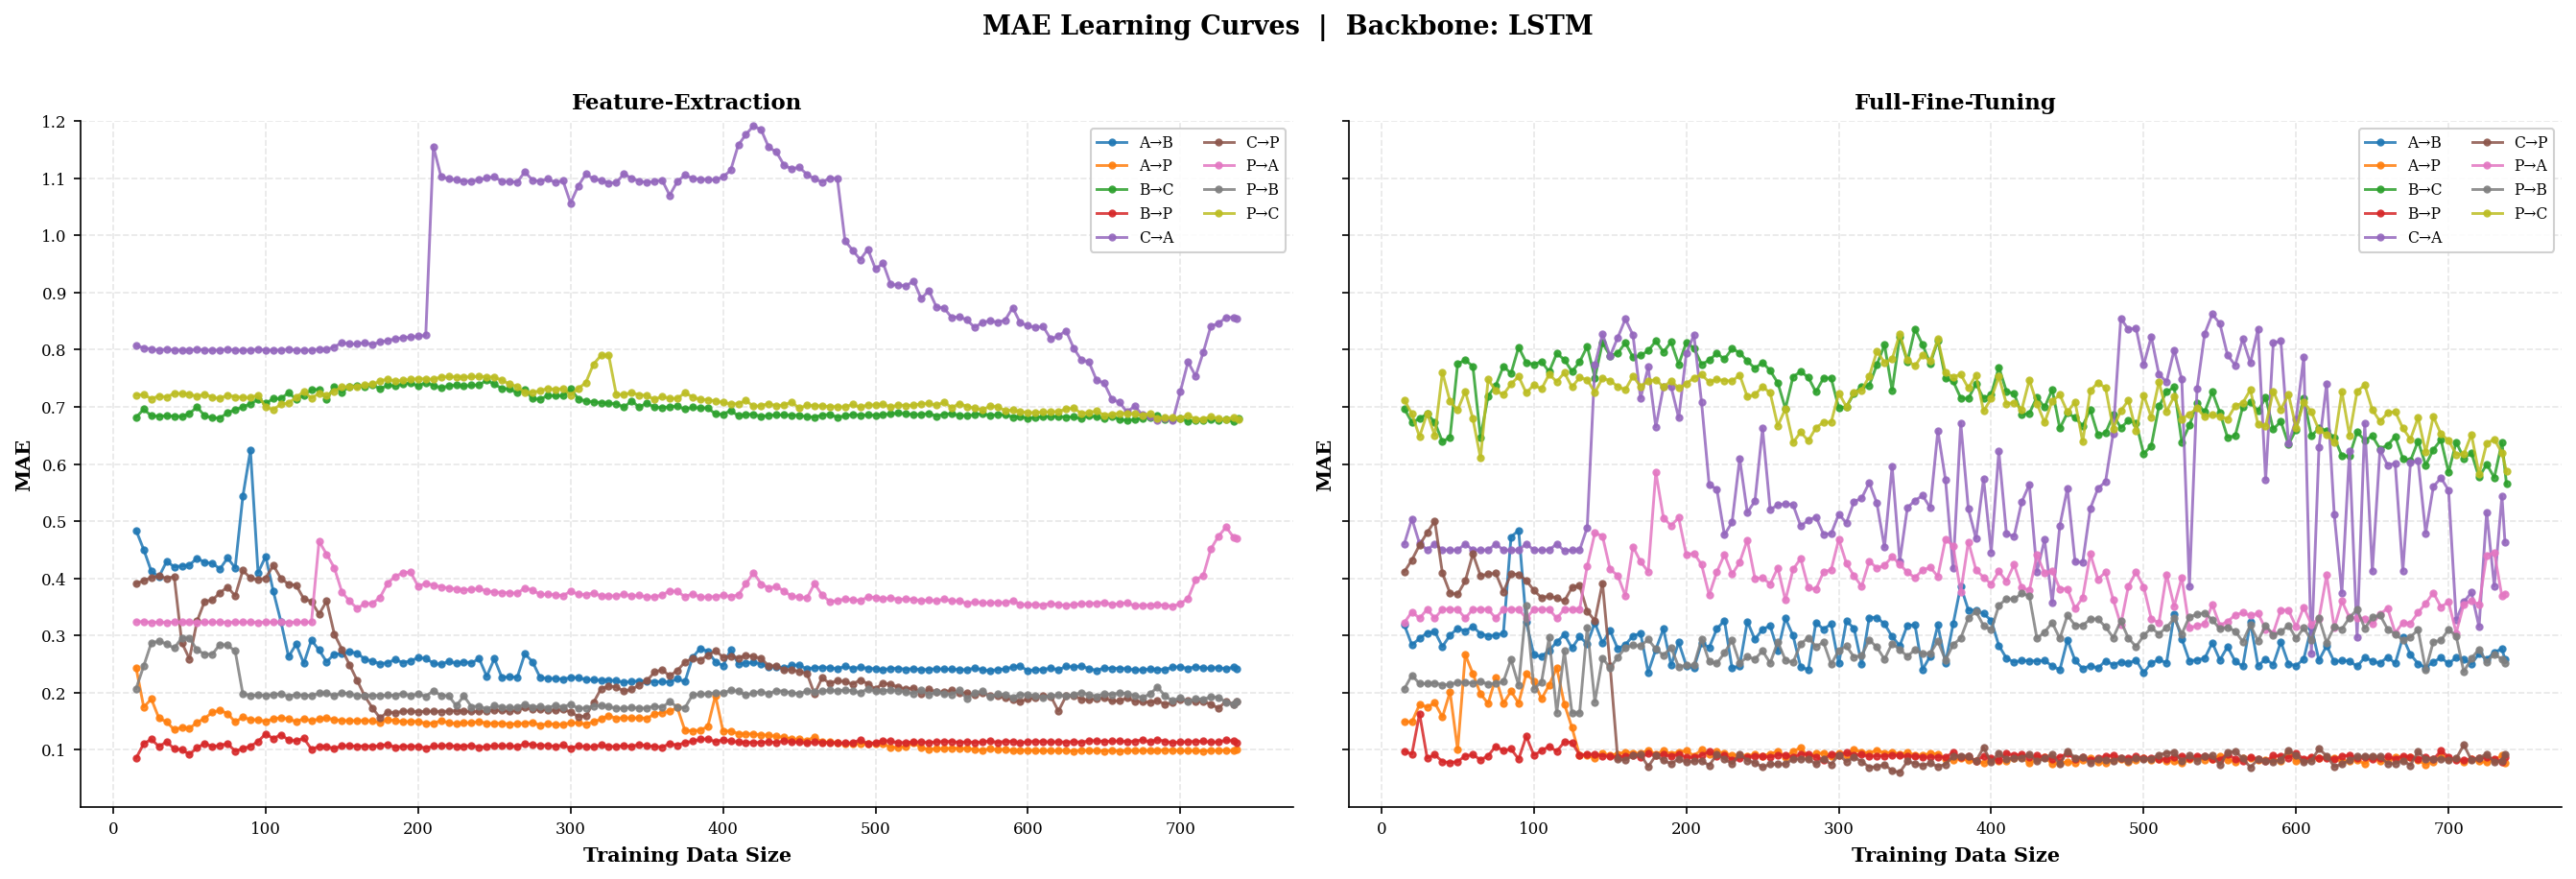


  FULL MAE TABLE  |  Backbone: LSTM  |  Method: Feature-Extraction
  Rows = every training size  |  Columns = transfer settings
  train_size  A→B         A→P         B→C         B→P         C→A         C→P         P→A         P→B         P→C         
  ------------------------------------------------------------------------------------------------------------------------
  0           0.5323      0.4703      0.6802      0.1721      0.8092      0.3860      0.3492      0.2143      0.7227       ←zero-shot
  15          0.4840      0.2436      0.6815      0.0856      0.8071      0.3906      0.3243      0.2073      0.7207      
  20          0.4504      0.1750      0.6959      0.1109      0.8030      0.3963      0.3243      0.2468      0.7213      
  25          0.4123      0.1890      0.6843      0.1187      0.8010      0.4014      0.3229      0.2873      0.7142      
  30          0.4028      0.1555      0.6838      0.1061      0.7989      0.4037      0.3234      0.2901      0.7190      

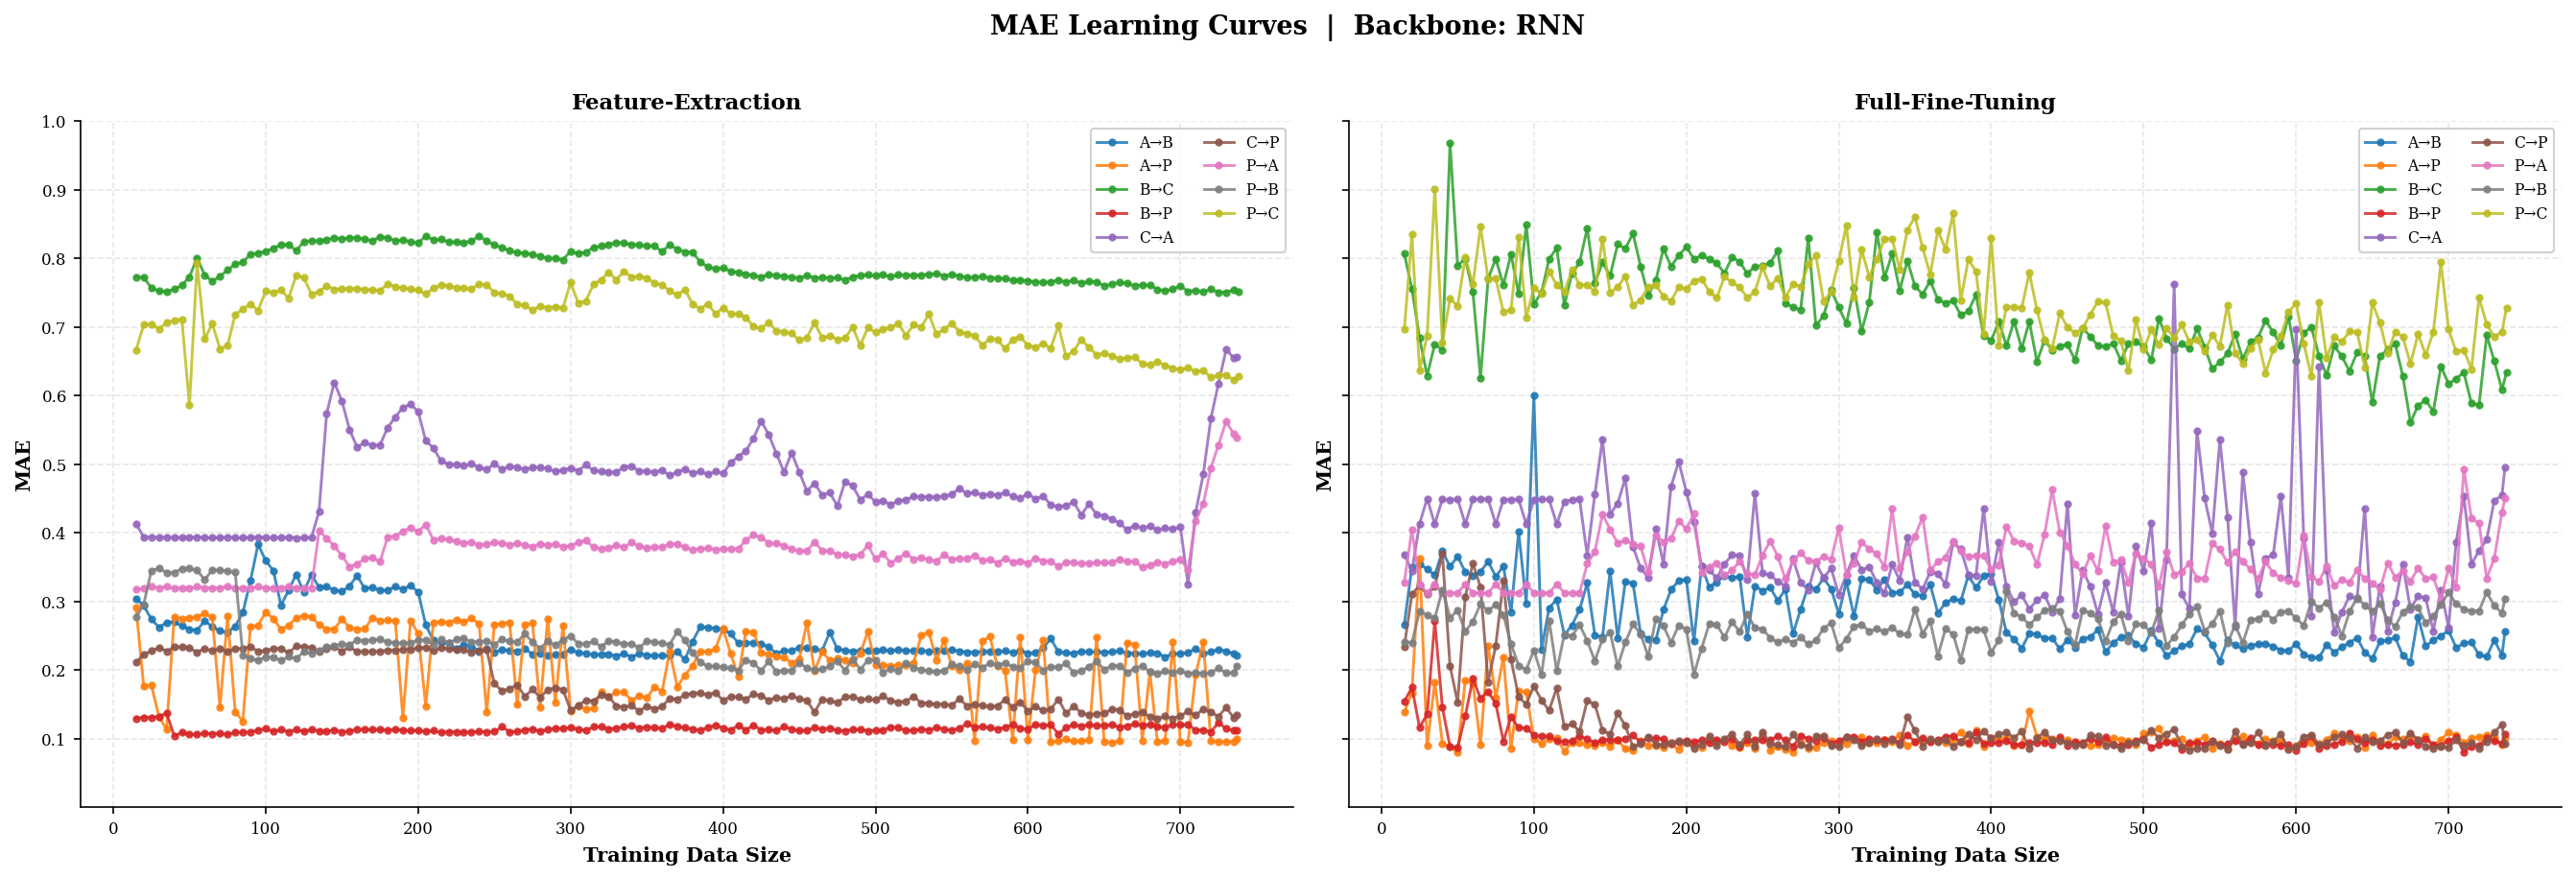


  FULL MAE TABLE  |  Backbone: RNN  |  Method: Feature-Extraction
  Rows = every training size  |  Columns = transfer settings
  train_size  A→B         A→P         B→C         B→P         C→A         C→P         P→A         P→B         P→C         
  ------------------------------------------------------------------------------------------------------------------------
  0           0.3316      0.3055      0.7728      0.1525      0.5854      0.2057      0.3317      0.2390      0.7165       ←zero-shot
  15          0.3038      0.2903      0.7723      0.1293      0.4131      0.2112      0.3172      0.2765      0.6662      
  20          0.2932      0.1757      0.7720      0.1307      0.3931      0.2222      0.3192      0.2956      0.7030      
  25          0.2738      0.1779      0.7567      0.1306      0.3937      0.2276      0.3211      0.3445      0.7038      
  30          0.2623      0.1318      0.7519      0.1320      0.3925      0.2324      0.3193      0.3482      0.6969      


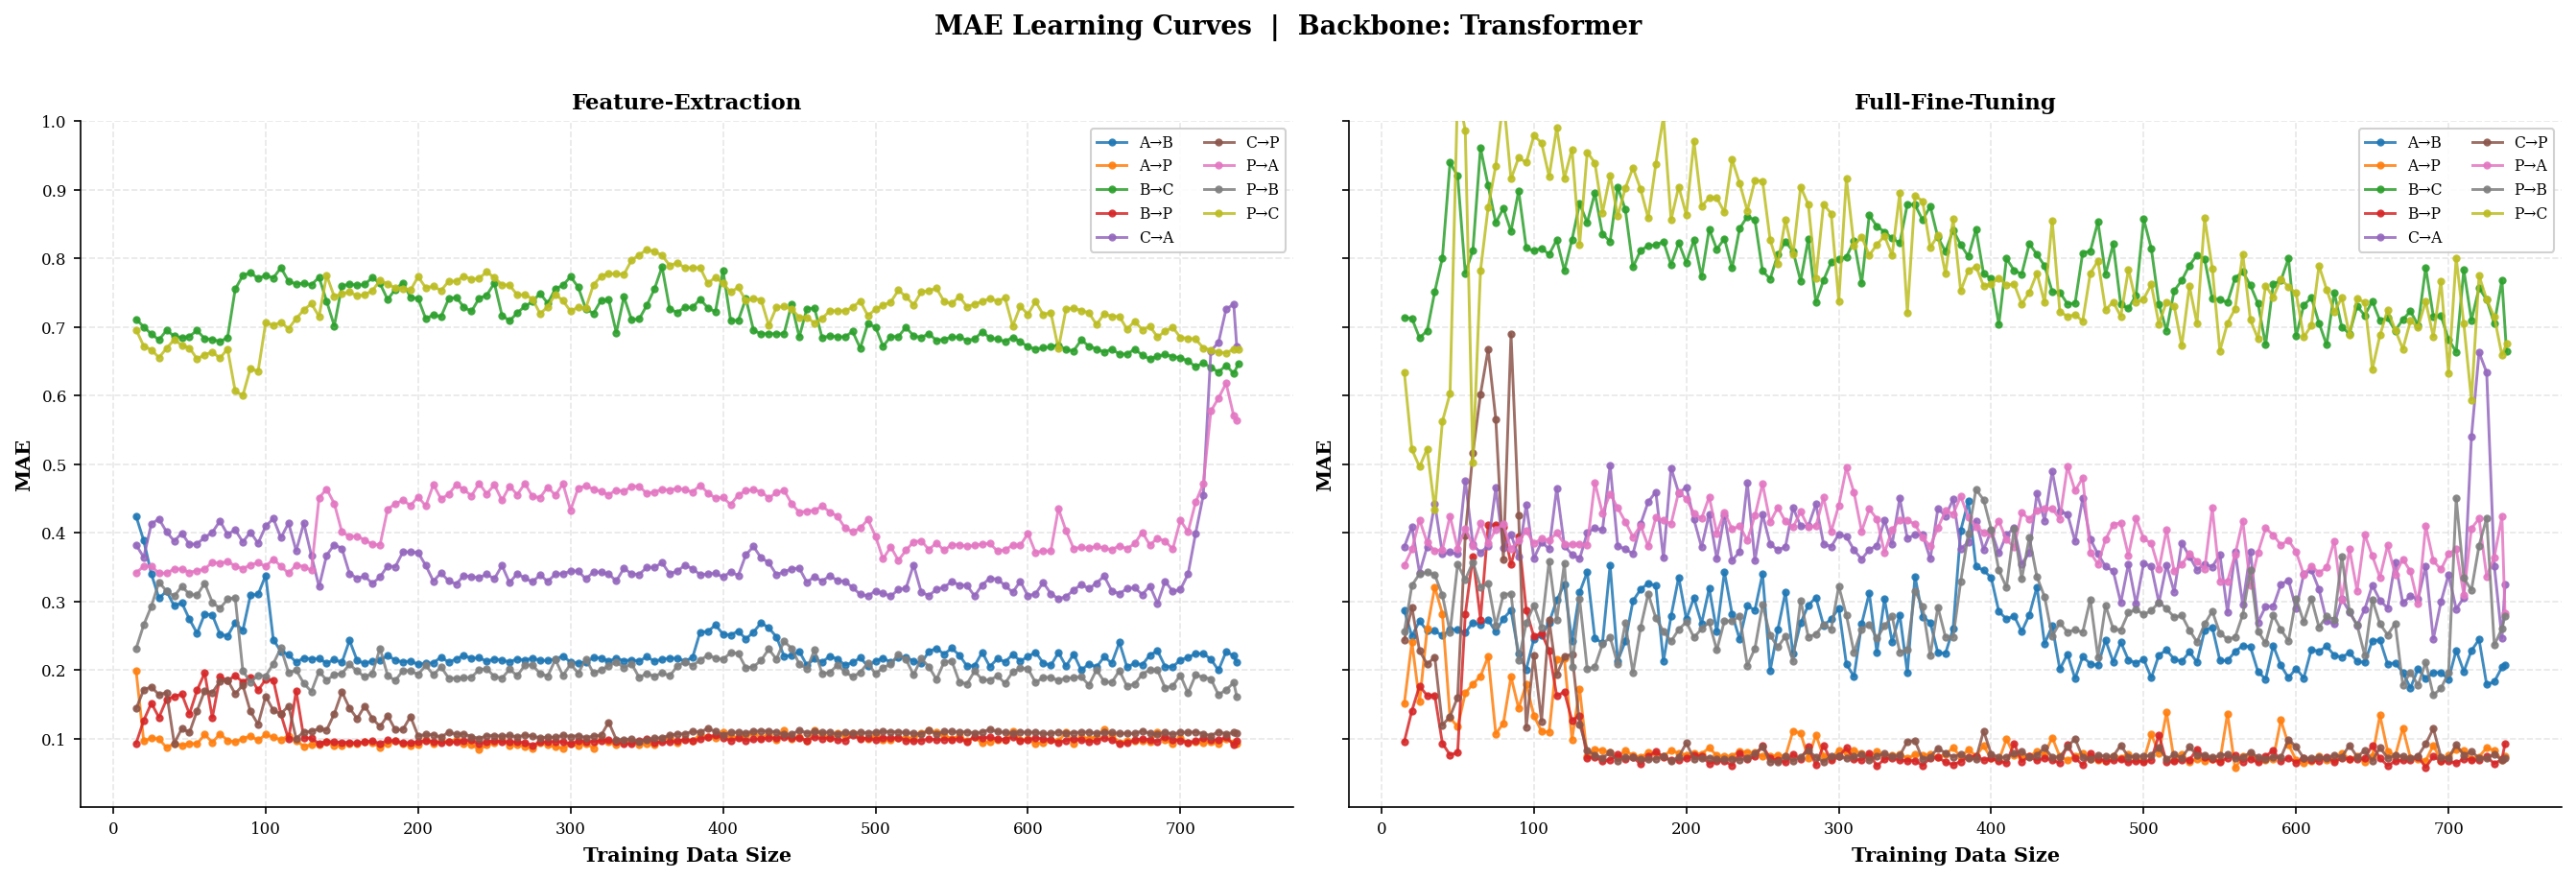


  FULL MAE TABLE  |  Backbone: Transformer  |  Method: Feature-Extraction
  Rows = every training size  |  Columns = transfer settings
  train_size  A→B         A→P         B→C         B→P         C→A         C→P         P→A         P→B         P→C         
  ------------------------------------------------------------------------------------------------------------------------
  0           0.4676      0.2420      0.7109      0.0962      0.3360      0.1451      0.3758      0.2208      0.7046       ←zero-shot
  15          0.4238      0.1987      0.7112      0.0929      0.3822      0.1435      0.3415      0.2310      0.6957      
  20          0.3884      0.0962      0.6998      0.1263      0.3641      0.1710      0.3509      0.2656      0.6719      
  25          0.3398      0.1009      0.6894      0.1515      0.4129      0.1752      0.3511      0.2926      0.6665      
  30          0.3046      0.0990      0.6811      0.1308      0.4199      0.1639      0.3408      0.3278      0.655

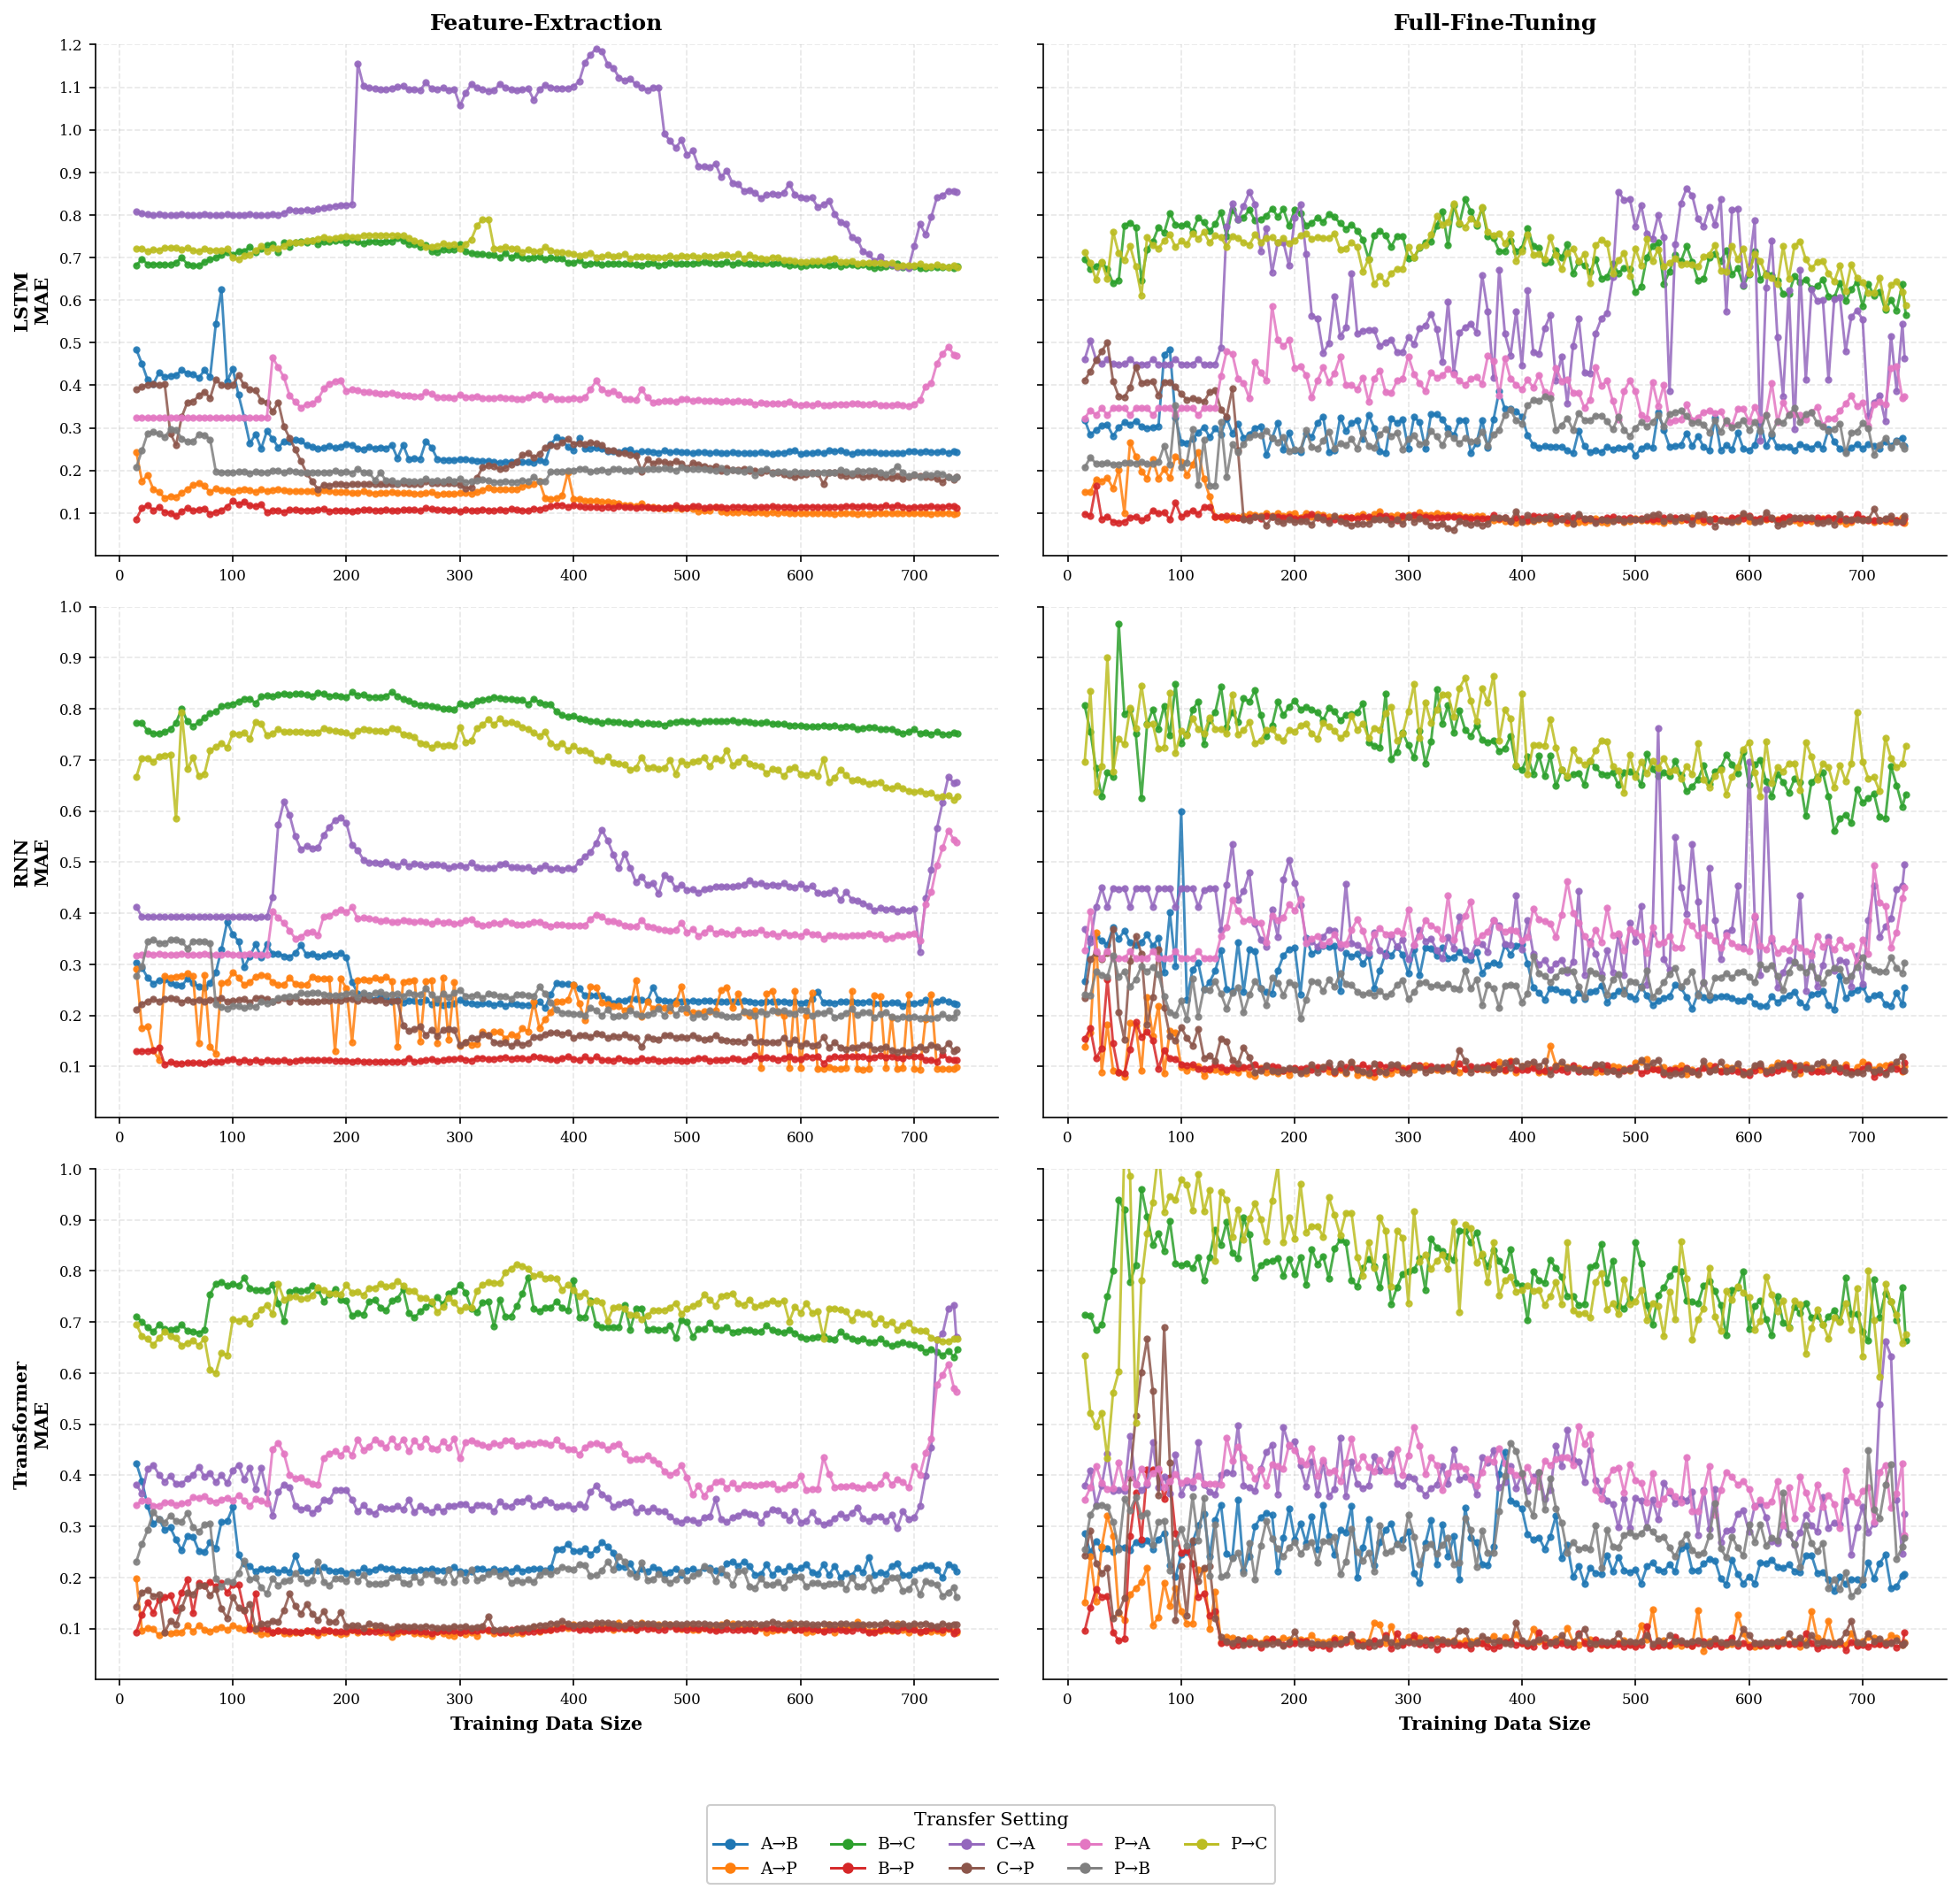


Done.


In [14]:
# =============================================================================
#  Progressive MAE Learning Curves + Full MAE Tables
#  For each backbone (RNN, LSTM, Transformer):
#    1. Two-panel figure with fixed y-axis per backbone
#    2. Full MAE table: one row per training size × scenario
#  Plus one combined figure showing all three backbones (6 panels)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

matplotlib.rcParams.update({
    "font.family":     "serif",
    "font.size":       10,
    "axes.titlesize":  12,
    "axes.labelsize":  11,
    "legend.fontsize": 7.5,
    "figure.dpi":      150,
    "savefig.dpi":     300,
})

# ── locate CSV ────────────────────────────────────────────────────────────────
CSV_PATH = None

# Uncomment and edit if auto-search fails:
# CSV_PATH = "/opt/domain-adaptation-people-counting/results/progressive_data_efficiency/all_progressive_data_efficiency_homogeneous.csv"

if CSV_PATH is None:
    _search_root = Path.cwd()
    for _ in range(5):
        _found = list(_search_root.rglob(
            "all_progressive_data_efficiency_homogeneous.csv"))
        if _found:
            CSV_PATH = str(_found[0])
            break
        _search_root = _search_root.parent
    if CSV_PATH is None:
        _hard = Path(
            "/opt/domain-adaptation-people-counting/results/"
            "progressive_data_efficiency/"
            "all_progressive_data_efficiency_homogeneous.csv"
        )
        if _hard.exists():
            CSV_PATH = str(_hard)

if CSV_PATH is None:
    raise FileNotFoundError(
        "Cannot find the CSV. Set CSV_PATH manually at the top of this script."
    )

# ── load ─────────────────────────────────────────────────────────────────────
p  = Path(CSV_PATH)
print(f"Reading: {p}")
df = pd.read_csv(p)
print(f"Loaded : {len(df):,} rows\n")

df["scenario"] = (df["scenario"]
                  .astype(str)
                  .str.replace("Room_", "", regex=False)
                  .str.replace(" → ", "→", regex=False))

SCENARIOS = sorted(df["scenario"].unique())
BACKBONES = sorted(df["model"].unique())
METHODS   = ["Feature-Extraction", "Full-Fine-Tuning"]

COLORS = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22",
]
SCENARIO_COLOR = {sc: COLORS[i % len(COLORS)] for i, sc in enumerate(SCENARIOS)}

# ── fixed y-axis per backbone ─────────────────────────────────────────────────
Y_LIMITS = {
    "LSTM":        (0.0, 1.2),
    "RNN":         (0.0, 1.0),
    "Transformer": (0.0, 1.0),
}
Y_TICKS = {
    "LSTM":        [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2],
    "RNN":         [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "Transformer": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
}

OUT_DIR = p.parent / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

THICK = "=" * 130
THIN  = "-" * 130


# ── helpers ───────────────────────────────────────────────────────────────────
def _f(v, d=4):
    try:
        if v is None or np.isnan(float(v)):
            return "N/A"
        return f"{v:.{d}f}"
    except (TypeError, ValueError):
        return "N/A"


def setup_ax(ax, backbone, method,
             show_legend=False,
             show_xlabel=True,
             ylabel="MAE"):
    """Apply titles, labels, grid, fixed y-axis ticks."""
    ax.set_title(f"{method}", fontsize=11, fontweight="bold")
    if show_xlabel:
        ax.set_xlabel("Training Data Size", fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10, fontweight="bold")
    ax.set_ylim(Y_LIMITS.get(backbone, (0.0, 1.0)))
    ax.set_yticks(Y_TICKS.get(backbone,
                  [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]))
    ax.grid(True, alpha=0.3, linestyle="--")
    if show_legend:
        ax.legend(loc="upper right", ncol=2, frameon=True, framealpha=0.9)


def plot_method_on_ax(ax, df, backbone, method):
    """Draw all scenario lines for one backbone × method on ax."""
    sub = df[
        (df["model"]      == backbone) &
        (df["method"]     == method)   &
        (df["train_size"] >  0)
    ].copy()
    for scenario in SCENARIOS:
        s = sub[sub["scenario"] == scenario].sort_values("train_size")
        if len(s) == 0:
            continue
        ax.plot(
            s["train_size"].values,
            s["test_mae"].values,
            "o-", lw=1.4, ms=3,
            color=SCENARIO_COLOR[scenario],
            label=scenario, alpha=0.85,
        )


def print_full_mae_table(df, backbone, method):
    """One row per training size, columns = scenarios."""
    sub = df[
        (df["model"]  == backbone) &
        (df["method"] == method)
    ].copy()

    pivot = sub.pivot_table(
        index="train_size",
        columns="scenario",
        values="test_mae",
        aggfunc="first"
    ).sort_index()

    for sc in SCENARIOS:
        if sc not in pivot.columns:
            pivot[sc] = np.nan
    pivot = pivot[SCENARIOS]

    sc_width = 12
    header   = f"  {'train_size':<12}" + "".join(
        f"{sc:<{sc_width}}" for sc in SCENARIOS)
    print(header)
    print("  " + THIN[:len(header) - 2])

    for size, row in pivot.iterrows():
        tag  = " ←zero-shot" if int(size) == 0 else ""
        line = f"  {int(size):<12}"
        for sc in SCENARIOS:
            v    = row[sc]
            cell = f"{v:.4f}" if not np.isnan(v) else "N/A"
            line += f"{cell:<{sc_width}}"
        print(line + tag)

    print("  " + THIN[:len(header) - 2])
    print(f"  Rows: {len(pivot)}  "
          f"(1 zero-shot + {len(pivot) - 1} train sizes)")


# ═════════════════════════════════════════════════════════════════════════════
#  1. ONE FIGURE PER BACKBONE  (2 panels each)
# ═════════════════════════════════════════════════════════════════════════════
for backbone in BACKBONES:

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    fig.suptitle(
        f"MAE Learning Curves  |  Backbone: {backbone}",
        fontsize=13, fontweight="bold", y=1.01
    )

    for ax, method in zip(axes, METHODS):
        plot_method_on_ax(ax, df, backbone, method)
        setup_ax(ax, backbone, method, show_legend=True)

    plt.tight_layout()

    for ext in ["png", "pdf"]:
        out = OUT_DIR / f"progressive_mae_{backbone}_ws12.{ext}"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print(f"Saved: {out}")

    plt.show()
    plt.close()

    # ── full MAE tables ───────────────────────────────────────────────────────
    for method in METHODS:
        print()
        print(THICK)
        print(f"  FULL MAE TABLE  |  Backbone: {backbone}  "
              f"|  Method: {method}")
        print(f"  Rows = every training size  |  Columns = transfer settings")
        print(THICK)
        print_full_mae_table(df, backbone, method)

    print()


# ═════════════════════════════════════════════════════════════════════════════
#  2. COMBINED FIGURE — 3 rows (backbones) × 2 cols (methods)
#     - No suptitle
#     - No ws=12 anywhere
#     - No backbone name on y-axis — only "MAE"
#     - No per-panel legends — one shared legend at the bottom
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(
    3, 2,
    figsize=(18, 16),
    gridspec_kw={"hspace": 0.1, "wspace": 0.05}
)

# column headers (method names) on top row only
for col_idx, method in enumerate(METHODS):
    axes[0][col_idx].set_title(method, fontsize=12, fontweight="bold", pad=8)

for row_idx, backbone in enumerate(BACKBONES):
    for col_idx, method in enumerate(METHODS):
        ax = axes[row_idx][col_idx]
        plot_method_on_ax(ax, df, backbone, method)

        ax.set_ylim(Y_LIMITS.get(backbone, (0.0, 1.0)))
        ax.set_yticks(Y_TICKS.get(backbone,
                      [0.1, 0.2, 0.3, 0.4, 0.5, 0.6,
                       0.7, 0.8, 0.9, 1.0]))
        ax.grid(True, alpha=0.3, linestyle="--")

        # x-label only on bottom row
        if row_idx == len(BACKBONES) - 1:
            ax.set_xlabel("Training Data Size",
                          fontsize=10, fontweight="bold")

        # y-label only on left column — backbone name as row label
        if col_idx == 0:
            ax.set_ylabel(f"{backbone}\nMAE",
                          fontsize=10, fontweight="bold")
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

        # no per-panel legend
        ax.get_legend().remove() if ax.get_legend() else None

# ── single shared legend at the bottom ───────────────────────────────────────
handles = [
    plt.Line2D([0], [0], color=SCENARIO_COLOR[sc],
               marker="o", linestyle="-", lw=1.4, ms=5,
               label=sc)
    for sc in SCENARIOS
]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=5,
    fontsize=9,
    frameon=True,
    framealpha=0.95,
    bbox_to_anchor=(0.5, 0.01),
    title="Transfer Setting",
    title_fontsize=10,
)

for ext in ["png", "pdf"]:
    out = OUT_DIR / f"progressive_mae_ALL_backbones_ws12.{ext}"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved: {out}")

plt.show()
plt.close()

print("\nDone.")

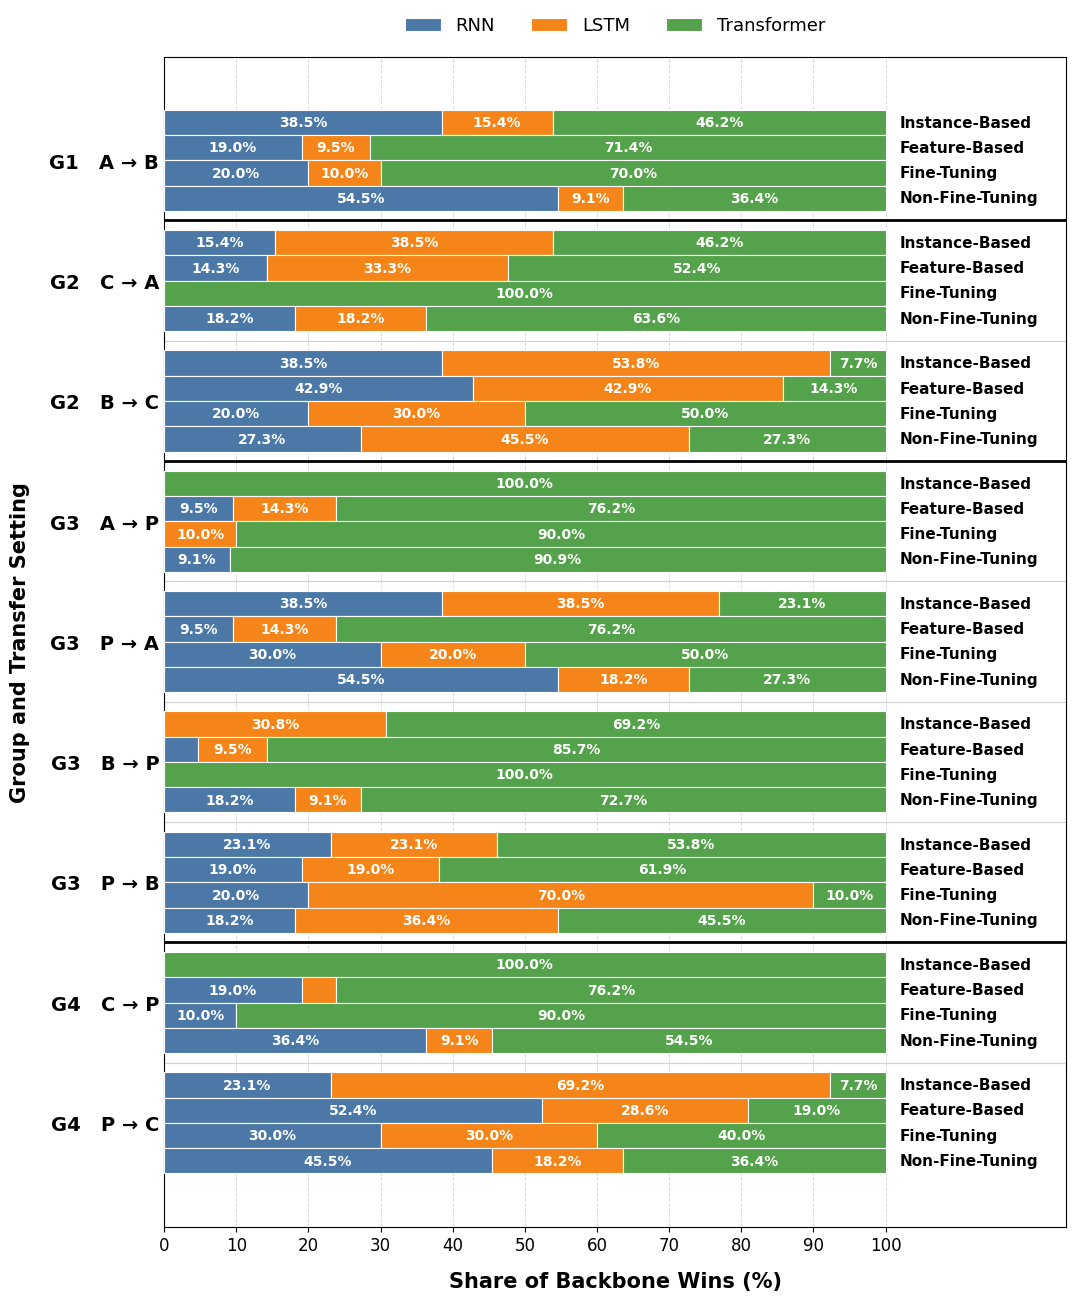

In [19]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Transfer settings and groups
# ============================================================

transfer_settings = [
    "A → B",
    "C → A",
    "B → C",
    "A → P",
    "P → A",
    "B → P",
    "P → B",
    "C → P",
    "P → C",
]

group_labels = [
    "G1",
    "G2",
    "G2",
    "G3",
    "G3",
    "G3",
    "G3",
    "G4",
    "G4",
]

combined_setting_labels = [
    f"{group}   {setting}"
    for group, setting in zip(group_labels, transfer_settings)
]


# ============================================================
# 2. Method-family names
# ============================================================

family_names = [
    "Instance-Based",
    "Feature-Based",
    "Fine-Tuning",
    "Non-Fine-Tuning",
]


# ============================================================
# 3. Win-count data
#
# Each row contains:
# [RNN wins, LSTM wins, Transformer wins]
# ============================================================

instance_based_counts = [
    [5, 2, 6],    # A → B
    [2, 5, 6],    # C → A
    [5, 7, 1],    # B → C
    [0, 0, 13],   # A → P
    [5, 5, 3],    # P → A
    [0, 4, 9],    # B → P
    [3, 3, 7],    # P → B
    [0, 0, 13],   # C → P
    [3, 9, 1],    # P → C
]

feature_based_counts = [
    [4, 2, 15],   # A → B
    [3, 7, 11],   # C → A
    [9, 9, 3],    # B → C
    [2, 3, 16],   # A → P
    [2, 3, 16],   # P → A
    [1, 2, 18],   # B → P
    [4, 4, 13],   # P → B
    [4, 1, 16],   # C → P
    [11, 6, 4],   # P → C
]

fine_tuning_counts = [
    [2, 1, 7],    # A → B
    [0, 0, 10],   # C → A
    [2, 3, 5],    # B → C
    [0, 1, 9],    # A → P
    [3, 2, 5],    # P → A
    [0, 0, 10],   # B → P
    [2, 7, 1],    # P → B
    [1, 0, 9],    # C → P
    [3, 3, 4],    # P → C
]

non_fine_tuning_counts = [
    [6, 1, 4],    # A → B
    [2, 2, 7],    # C → A
    [3, 5, 3],    # B → C
    [1, 0, 10],   # A → P
    [6, 2, 3],    # P → A
    [2, 1, 8],    # B → P
    [2, 4, 5],    # P → B
    [4, 1, 6],    # C → P
    [5, 2, 4],    # P → C
]


# ============================================================
# 4. Combine all method families
# ============================================================

all_family_counts = [
    instance_based_counts,
    feature_based_counts,
    fine_tuning_counts,
    non_fine_tuning_counts,
]


# ============================================================
# 5. Convert counts to percentages
# ============================================================

def counts_to_percentages(count_data):
    """
    Convert backbone win counts into percentages.

    Each row becomes:
    RNN + LSTM + Transformer = 100%.
    """
    counts = np.asarray(count_data, dtype=float)

    if counts.ndim != 2 or counts.shape[1] != 3:
        raise ValueError(
            "Each row must contain exactly three values: "
            "[RNN, LSTM, Transformer]."
        )

    row_totals = counts.sum(axis=1, keepdims=True)

    if np.any(row_totals == 0):
        raise ValueError("At least one row has zero total wins.")

    return counts / row_totals * 100.0


all_family_percentages = [
    counts_to_percentages(family_counts)
    for family_counts in all_family_counts
]


# ============================================================
# 6. Percentage-label function
# ============================================================

def add_percentage_labels(
    ax,
    bars,
    values,
    left_offsets,
    minimum_width=7.0,
):
    """
    Add percentage labels inside sufficiently wide segments.
    """
    for bar, value, left in zip(
        bars,
        values,
        left_offsets,
    ):
        if value < minimum_width:
            continue

        x_position = left + value / 2.0
        y_position = bar.get_y() + bar.get_height() / 2.0

        ax.text(
            x_position,
            y_position,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="white",
            clip_on=True,
        )


# ============================================================
# 7. Plot settings
# ============================================================

number_of_settings = len(transfer_settings)
y_positions = np.arange(number_of_settings)

# Thicker bars for better readability
bar_height = 0.21

# Four bars around each transfer-setting center
family_offsets = np.array([
    -1.5,
    -0.5,
    0.5,
    1.5,
]) * bar_height


# ============================================================
# 8. Fixed backbone colors
# ============================================================

RNN_COLOR = "#4C78A8"
LSTM_COLOR = "#F58518"
TRANSFORMER_COLOR = "#54A24B"


# ============================================================
# 9. Create the merged 2D figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 15),
)


# ============================================================
# 10. Draw grouped 100% stacked horizontal bars
# ============================================================

for family_index, percentages in enumerate(
    all_family_percentages
):
    rnn_values = percentages[:, 0]
    lstm_values = percentages[:, 1]
    transformer_values = percentages[:, 2]

    current_y = (
        y_positions
        + family_offsets[family_index]
    )

    # RNN segment
    rnn_bars = ax.barh(
        current_y,
        rnn_values,
        height=bar_height,
        color=RNN_COLOR,
        edgecolor="white",
        linewidth=0.8,
        label="RNN" if family_index == 0 else None,
        zorder=3,
    )

    # LSTM segment
    lstm_bars = ax.barh(
        current_y,
        lstm_values,
        left=rnn_values,
        height=bar_height,
        color=LSTM_COLOR,
        edgecolor="white",
        linewidth=0.8,
        label="LSTM" if family_index == 0 else None,
        zorder=3,
    )

    # Transformer segment
    transformer_left = (
        rnn_values
        + lstm_values
    )

    transformer_bars = ax.barh(
        current_y,
        transformer_values,
        left=transformer_left,
        height=bar_height,
        color=TRANSFORMER_COLOR,
        edgecolor="white",
        linewidth=0.8,
        label="Transformer" if family_index == 0 else None,
        zorder=3,
    )

    # Percentage labels
    add_percentage_labels(
        ax=ax,
        bars=rnn_bars,
        values=rnn_values,
        left_offsets=np.zeros(number_of_settings),
    )

    add_percentage_labels(
        ax=ax,
        bars=lstm_bars,
        values=lstm_values,
        left_offsets=rnn_values,
    )

    add_percentage_labels(
        ax=ax,
        bars=transformer_bars,
        values=transformer_values,
        left_offsets=transformer_left,
    )

    # Method-family labels on the right
    for setting_index in range(number_of_settings):
        ax.text(
            102.0,
            current_y[setting_index],
            family_names[family_index],
            va="center",
            ha="left",
            fontsize=11,
            fontweight="bold",
            color="black",
        )


# ============================================================
# 11. Separators between transfer settings and groups
# ============================================================

# Thin lines between individual transfer settings
for separator_position in y_positions[:-1] + 0.5:
    ax.axhline(
        separator_position,
        color="lightgray",
        linewidth=0.9,
        zorder=1,
    )

# Thick lines between G1, G2, G3, and G4
group_separator_positions = [
    0.5,   # between G1 and G2
    2.5,   # between G2 and G3
    6.5,   # between G3 and G4
]

for separator_position in group_separator_positions:
    ax.axhline(
        separator_position,
        color="black",
        linewidth=2.0,
        zorder=2,
    )


# ============================================================
# 12. Axis formatting
# ============================================================

ax.set_yticks(y_positions)

ax.set_yticklabels(
    combined_setting_labels,
    fontsize=14,
    fontweight="bold",
)

ax.invert_yaxis()

# Space from 100 to 125 is used for family labels
ax.set_xlim(0, 125)

ax.set_xlabel(
    "Share of Backbone Wins (%)",
    fontsize=15,
    fontweight="bold",
    labelpad=12,
)

ax.set_ylabel(
    "Group and Transfer Setting",
    fontsize=15,
    fontweight="bold",
    labelpad=14,
)


ax.set_xticks(
    np.arange(0, 101, 10)
)

ax.tick_params(
    axis="x",
    labelsize=12,
)

ax.tick_params(
    axis="y",
    length=0,
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.45,
    zorder=0,
)

ax.set_axisbelow(True)


# ============================================================
# 13. Legend
# ============================================================

ax.legend(
    
    loc="lower center",
    bbox_to_anchor=(0.5, 1.005),
    ncol=3,
    frameon=False,
    fontsize=13,
    title_fontsize=14,
)


# ============================================================
# 14. Improve figure layout
# ============================================================

fig.subplots_adjust(
    left=0.14,
    right=0.96,
    bottom=0.10,
    top=0.88,
)


# ============================================================
# 15. Save the merged figure
# ============================================================

fig.savefig(
    "merged_2d_backbone_win_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    "merged_2d_backbone_win_distribution.pdf",
    bbox_inches="tight",
)

fig.savefig(
    "merged_2d_backbone_win_distribution.svg",
    bbox_inches="tight",
)


# ============================================================
# 16. Show the figure
# ============================================================

plt.show()

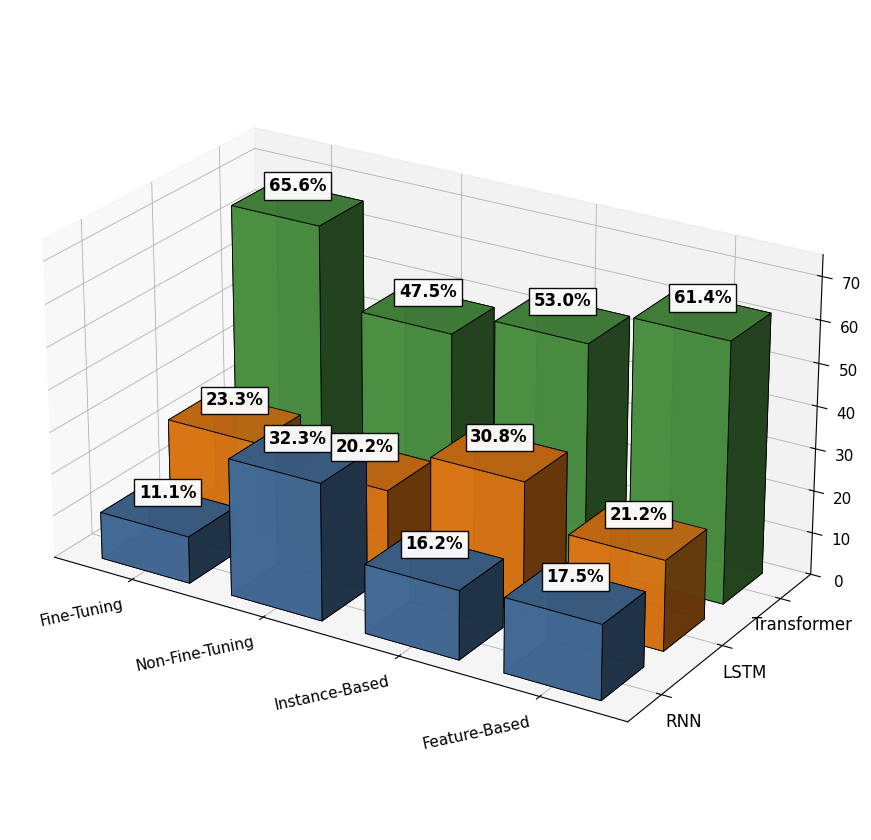

In [18]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Data
# ============================================================

categories = [
    "Fine-Tuning",
    "Non-Fine-Tuning",
    "Instance-Based",
    "Feature-Based",
]

backbones = [
    "RNN",
    "LSTM",
    "Transformer",
]

# Percentage values from the table
percentages = np.array([
    [11.1, 23.3, 65.6],  # Fine-Tuning
    [32.3, 20.2, 47.5],  # Non-Fine-Tuning
    [16.2, 30.8, 53.0],  # Instance-Based
    [17.5, 21.2, 61.4],  # Feature-Based
])


# ============================================================
# 2. Plot positions
# ============================================================

number_of_categories = len(categories)
number_of_backbones = len(backbones)

x_positions = np.arange(number_of_categories)
y_positions = np.arange(number_of_backbones)

x_grid, y_grid = np.meshgrid(
    x_positions,
    y_positions,
    indexing="ij",
)

x = x_grid.ravel()
y = y_grid.ravel()
z = np.zeros_like(x, dtype=float)

# Slightly thicker bars
dx = np.full_like(x, 0.68, dtype=float)
dy = np.full_like(y, 0.68, dtype=float)

# Bar heights are the percentages
dz = percentages.ravel()


# ============================================================
# 3. Fixed colors
# ============================================================

RNN_COLOR = "#4C78A8"
LSTM_COLOR = "#F58518"
TRANSFORMER_COLOR = "#54A24B"

backbone_colors = [
    RNN_COLOR,
    LSTM_COLOR,
    TRANSFORMER_COLOR,
]

bar_colors = [
    backbone_colors[backbone_index]
    for _ in categories
    for backbone_index in range(number_of_backbones)
]


# ============================================================
# 4. Create 3D figure
# ============================================================

fig = plt.figure(
    figsize=(14, 10),
)

ax = fig.add_subplot(
    111,
    projection="3d",
)


# ============================================================
# 5. Draw bars
# ============================================================

ax.bar3d(
    x,
    y,
    z,
    dx,
    dy,
    dz,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
    shade=True,
    alpha=0.95,
)


# ============================================================
# 6. Add percentage labels only
#
# Each label is placed in a white square box above the bar.
# ============================================================

for category_index in range(number_of_categories):
    for backbone_index in range(number_of_backbones):

        percentage = percentages[
            category_index,
            backbone_index,
        ]

        ax.text(
            category_index + dx[0] / 2,
            backbone_index + dy[0] / 2,
            percentage + 2.0,
            f"{percentage:.1f}%",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color="black",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                boxstyle="square,pad=0.28",
                alpha=0.95,
            ),
        )


# ============================================================
# 7. Axis ticks and labels
# ============================================================

ax.set_xticks(
    x_positions + dx[0] / 2
)

ax.set_xticklabels(
    categories,
    fontsize=11,
    rotation=12,
    ha="right",
)

ax.set_yticks(
    y_positions + dy[0] / 2
)

ax.set_yticklabels(
    backbones,
    fontsize=12,
)


# ============================================================
# 8. Z-axis settings
# ============================================================

ax.set_zlim(
    0,
    75,
)

ax.set_zticks(
    np.arange(0, 76, 10)
)

ax.tick_params(
    axis="z",
    labelsize=11,
)


# ============================================================
# 9. Axis titles
# ============================================================


ax.set_zlabel(
    "Share of Wins (%)",
    fontsize=14,
    fontweight="bold",
    labelpad=12,
)


# ============================================================
# 10. Figure title
# ============================================================


# ============================================================
# 11. Viewing angle
# ============================================================

ax.view_init(
    elev=24,
    azim=-58,
)


# ============================================================
# 12. Improve 3D proportions
# ============================================================

ax.set_box_aspect(
    (
        number_of_categories * 1.35,
        number_of_backbones,
        2.8,
    )
)


# ============================================================
# 13. Improve grid appearance
# ============================================================

ax.xaxis._axinfo["grid"]["linewidth"] = 0.6
ax.yaxis._axinfo["grid"]["linewidth"] = 0.6
ax.zaxis._axinfo["grid"]["linewidth"] = 0.6

ax.xaxis._axinfo["grid"]["linestyle"] = "-"
ax.yaxis._axinfo["grid"]["linestyle"] = "-"
ax.zaxis._axinfo["grid"]["linestyle"] = "-"


# ============================================================
# 14. Improve layout
# ============================================================

fig.subplots_adjust(
    left=0.02,
    right=0.94,
    bottom=0.08,
    top=0.90,
)


# ============================================================
# 15. Save figure
# ============================================================

fig.savefig(
    "backbone_wins_3d_bar_percentage_only.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    "backbone_wins_3d_bar_percentage_only.pdf",
    bbox_inches="tight",
)

fig.savefig(
    "backbone_wins_3d_bar_percentage_only.svg",
    bbox_inches="tight",
)


# ============================================================
# 16. Show figure
# ============================================================

plt.show()

Created:
  experimental_pipeline.svg
  experimental_pipeline.pdf
  experimental_pipeline.png


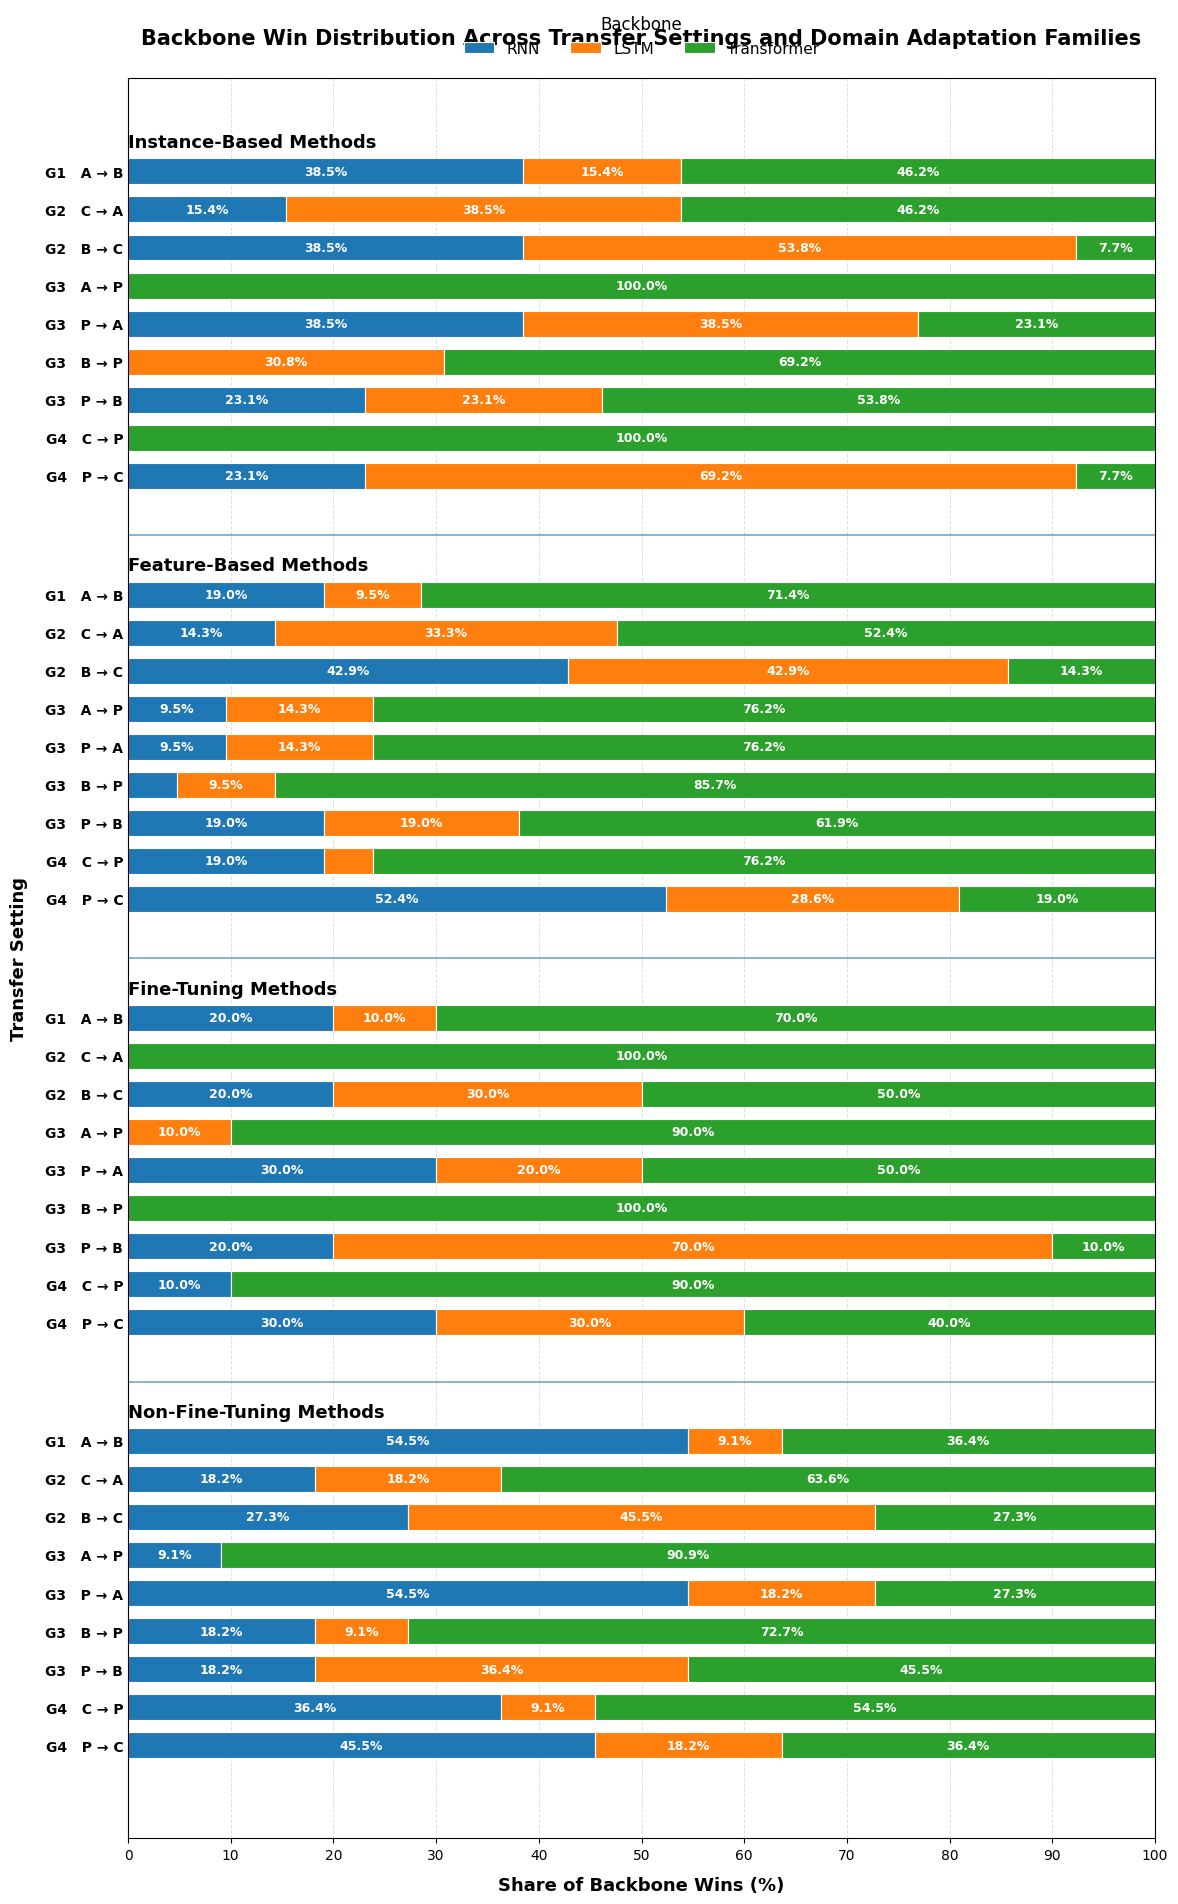

In [13]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Transfer settings and groups
# ============================================================

transfer_settings = [
    "A → B",
    "C → A",
    "B → C",
    "A → P",
    "P → A",
    "B → P",
    "P → B",
    "C → P",
    "P → C",
]

group_labels = [
    "G1",
    "G2",
    "G2",
    "G3",
    "G3",
    "G3",
    "G3",
    "G4",
    "G4",
]

setting_labels = [
    f"{group}   {setting}"
    for group, setting in zip(group_labels, transfer_settings)
]


# ============================================================
# 2. Method-family names
# ============================================================

family_names = [
    "Instance-Based Methods",
    "Feature-Based Methods",
    "Fine-Tuning Methods",
    "Non-Fine-Tuning Methods",
]


# ============================================================
# 3. Win-count data
#
# Each row:
# [RNN wins, LSTM wins, Transformer wins]
# ============================================================

instance_based_counts = [
    [5, 2, 6],    # A → B
    [2, 5, 6],    # C → A
    [5, 7, 1],    # B → C
    [0, 0, 13],   # A → P
    [5, 5, 3],    # P → A
    [0, 4, 9],    # B → P
    [3, 3, 7],    # P → B
    [0, 0, 13],   # C → P
    [3, 9, 1],    # P → C
]

feature_based_counts = [
    [4, 2, 15],   # A → B
    [3, 7, 11],   # C → A
    [9, 9, 3],    # B → C
    [2, 3, 16],   # A → P
    [2, 3, 16],   # P → A
    [1, 2, 18],   # B → P
    [4, 4, 13],   # P → B
    [4, 1, 16],   # C → P
    [11, 6, 4],   # P → C
]

fine_tuning_counts = [
    [2, 1, 7],    # A → B
    [0, 0, 10],   # C → A
    [2, 3, 5],    # B → C
    [0, 1, 9],    # A → P
    [3, 2, 5],    # P → A
    [0, 0, 10],   # B → P
    [2, 7, 1],    # P → B
    [1, 0, 9],    # C → P
    [3, 3, 4],    # P → C
]

non_fine_tuning_counts = [
    [6, 1, 4],    # A → B
    [2, 2, 7],    # C → A
    [3, 5, 3],    # B → C
    [1, 0, 10],   # A → P
    [6, 2, 3],    # P → A
    [2, 1, 8],    # B → P
    [2, 4, 5],    # P → B
    [4, 1, 6],    # C → P
    [5, 2, 4],    # P → C
]

all_family_counts = [
    instance_based_counts,
    feature_based_counts,
    fine_tuning_counts,
    non_fine_tuning_counts,
]


# ============================================================
# 4. Convert counts to percentages
# ============================================================

def counts_to_percentages(count_data):
    """
    Convert each row of counts to percentages.

    Every output row sums to 100%.
    """
    counts = np.asarray(count_data, dtype=float)

    if counts.ndim != 2 or counts.shape[1] != 3:
        raise ValueError(
            "Each row must contain [RNN, LSTM, Transformer]."
        )

    totals = counts.sum(axis=1, keepdims=True)

    if np.any(totals == 0):
        raise ValueError("A row contains zero total wins.")

    return counts / totals * 100.0


all_family_percentages = [
    counts_to_percentages(family_counts)
    for family_counts in all_family_counts
]


# ============================================================
# 5. Add labels inside bar segments
# ============================================================

def add_segment_labels(
    ax,
    bars,
    values,
    left_values,
    minimum_width=7.0,
):
    """
    Add percentage labels inside sufficiently wide segments.
    """
    for bar, value, left in zip(bars, values, left_values):
        if value < minimum_width:
            continue

        x = left + value / 2.0
        y = bar.get_y() + bar.get_height() / 2.0

        ax.text(
            x,
            y,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="white",
        )


# ============================================================
# 6. Fixed backbone colors
#
# Use the first three colors from Matplotlib's default cycle.
# ============================================================

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

RNN_COLOR = default_colors[0]
LSTM_COLOR = default_colors[1]
TRANSFORMER_COLOR = default_colors[2]


# ============================================================
# 7. Calculate y positions
#
# Nine bars are placed in each family block.
# Additional spacing separates the four families.
# ============================================================

bars_per_family = len(transfer_settings)

bar_spacing = 0.85
family_gap = 1.8
bar_height = 0.58

all_y_positions = []
family_start_positions = []
family_end_positions = []

current_position = 0.0

for _ in family_names:
    family_start_positions.append(current_position)

    positions = (
        current_position
        + np.arange(bars_per_family) * bar_spacing
    )

    all_y_positions.append(positions)

    family_end_positions.append(positions[-1])

    current_position = (
        positions[-1]
        + bar_spacing
        + family_gap
    )


# ============================================================
# 8. Create one tall merged figure
# ============================================================

fig, ax = plt.subplots(figsize=(13, 20))


# ============================================================
# 9. Draw the four family blocks
# ============================================================

legend_added = False

for family_index, percentages in enumerate(
    all_family_percentages
):
    y_positions = all_y_positions[family_index]

    rnn_values = percentages[:, 0]
    lstm_values = percentages[:, 1]
    transformer_values = percentages[:, 2]

    # RNN
    rnn_bars = ax.barh(
        y_positions,
        rnn_values,
        height=bar_height,
        color=RNN_COLOR,
        edgecolor="white",
        linewidth=0.8,
        label="RNN" if not legend_added else None,
    )

    # LSTM
    lstm_bars = ax.barh(
        y_positions,
        lstm_values,
        left=rnn_values,
        height=bar_height,
        color=LSTM_COLOR,
        edgecolor="white",
        linewidth=0.8,
        label="LSTM" if not legend_added else None,
    )

    transformer_left = rnn_values + lstm_values

    # Transformer
    transformer_bars = ax.barh(
        y_positions,
        transformer_values,
        left=transformer_left,
        height=bar_height,
        color=TRANSFORMER_COLOR,
        edgecolor="white",
        linewidth=0.8,
        label="Transformer" if not legend_added else None,
    )

    legend_added = True

    # Labels inside the bars
    add_segment_labels(
        ax=ax,
        bars=rnn_bars,
        values=rnn_values,
        left_values=np.zeros(bars_per_family),
    )

    add_segment_labels(
        ax=ax,
        bars=lstm_bars,
        values=lstm_values,
        left_values=rnn_values,
    )

    add_segment_labels(
        ax=ax,
        bars=transformer_bars,
        values=transformer_values,
        left_values=transformer_left,
    )

    # Family heading
    heading_y = y_positions[0] - 0.65

    ax.text(
        0,
        heading_y,
        family_names[family_index],
        ha="left",
        va="center",
        fontsize=13,
        fontweight="bold",
        clip_on=False,
    )

    # Light separator after each family except the last
    if family_index < len(family_names) - 1:
        separator_y = (
            y_positions[-1]
            + bar_spacing / 2.0
            + family_gap / 2.0
        )

        ax.axhline(
            separator_y,
            linewidth=1.4,
            alpha=0.55,
        )


# ============================================================
# 10. Create all y-axis labels
# ============================================================

flat_y_positions = np.concatenate(all_y_positions)

all_setting_labels = (
    setting_labels
    * len(family_names)
)

ax.set_yticks(flat_y_positions)

ax.set_yticklabels(
    all_setting_labels,
    fontsize=10,
    fontweight="bold",
)

ax.invert_yaxis()


# ============================================================
# 11. Axis formatting
# ============================================================

ax.set_xlim(0, 100)

ax.set_xticks(
    np.arange(0, 101, 10)
)

ax.set_xlabel(
    "Share of Backbone Wins (%)",
    fontsize=13,
    fontweight="bold",
    labelpad=10,
)

ax.set_ylabel(
    "Transfer Setting",
    fontsize=13,
    fontweight="bold",
    labelpad=12,
)

ax.set_title(
    "Backbone Win Distribution Across Transfer Settings "
    "and Domain Adaptation Families",
    fontsize=15,
    fontweight="bold",
    pad=25,
)

ax.tick_params(
    axis="x",
    labelsize=10,
)

ax.tick_params(
    axis="y",
    length=0,
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.4,
)

ax.set_axisbelow(True)


# ============================================================
# 12. Legend
# ============================================================

ax.legend(
    title="Backbone",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.005),
    ncol=3,
    frameon=False,
    fontsize=11,
    title_fontsize=12,
)


# ============================================================
# 13. Layout and export
# ============================================================

fig.subplots_adjust(
    left=0.18,
    right=0.97,
    bottom=0.06,
    top=0.94,
)

fig.savefig(
    "backbone_wins_family_blocks.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    "backbone_wins_family_blocks.pdf",
    bbox_inches="tight",
)

fig.savefig(
    "backbone_wins_family_blocks.svg",
    bbox_inches="tight",
)

plt.show()